# DocVQA Document Visual Question Answering Benchmark Analysis

## Executive Summary

**Dataset:** DocVQA_mini - Document Visual Question Answering  
**Total Samples:** 500 document Q&A pairs per phase  
**Task:** Answer questions about document images  
**Evaluation Metrics:** GT in Pred (PRIMARY), ANLS, Exact Match, Substring Match, Cosine Similarity

## Benchmark Structure

### QA1 Series: OCR + VLM Pipeline (Two-Step)
**Strategy:** Separate OCR extraction → LLM answers question based on extracted text

- **QA1a:** Azure Intelligence OCR + GPT-5-mini QA (simple prompt)
- **QA1b:** Mistral Document AI OCR + GPT-5-mini QA (generic prompt)
- **QA1c:** Azure Intelligence OCR + GPT-5-mini QA (task-aware prompt)

**Model Format:** `{parsing_model}__{qa_model}` (e.g., `azure_intelligence__gpt-5-mini`)

### QA2 Series: VLM Parse + QA Pipeline (Single VLM)
**Strategy:** Same VLM does both parsing and question answering

- **QA2a:** GPT-5-mini does parsing + QA (CoT prompt)
- **QA2b:** GPT-5-nano does parsing + QA (generic + CoT)
- **QA2c:** Claude Sonnet does parsing + QA

**Model Format:** `{model}__{model}` (e.g., `claude_sonnet__claude_sonnet`)

### QA3 Series: Direct VQA (Vision-to-Answer)
**Strategy:** VLM sees image directly and answers question

- **QA3a:** Claude Sonnet direct VQA
- **QA3b:** GPT-5-mini, GPT-5-nano, Claude Sonnet direct VQA

**Model Format:** `{model}` (e.g., `claude_sonnet`)

## Key Metrics

**PRIMARY METRIC:**
- **GT in Pred (Ground Truth in Prediction):** Main metric for QA tasks - checks if ground truth string (lowercase) is contained in prediction (lowercase). This is the most important metric for evaluating whether the model's answer contains the correct information.

**SECONDARY METRICS:**
- **ANLS (Average Normalized Levenshtein Similarity):** Standard QA metric, accounts for small variations (higher is better, 1.0 = perfect)
  - Threshold: 0.5 (standard for VQA tasks)
  - Handles multiple ground truth answers
- **EM (Exact Match):** Binary exact match (1.0 = exact, 0.0 = no match)
- **Substring Match:** Checks if prediction is substring of any ground truth or vice versa
- **Cosine Similarity:** Semantic similarity using embeddings (higher is better, 1.0 = identical)

## Analysis Focus Areas

1. **Pipeline Comparison:** QA1 (OCR+VLM) vs QA2 (VLM parse+QA) vs QA3 (direct VQA)
2. **OCR Quality Impact:** Does better OCR lead to better QA performance?
3. **Model Comparison:** Trade-offs between speed and accuracy
4. **Question Types:** Performance on different question types (What, Where, When, Who, How)
5. **Answer Lengths:** Performance on short vs long answers
6. **Field Extraction:** Accuracy on extracting specific fields (dates, names, numbers)

## Data Quality

⚠️ **Important:** This notebook identifies and filters out rows with:
- Empty predictions (blank or NaN values)
- Error values in error columns
- These rows are excluded from all metric calculations to ensure accurate evaluation

## To Run This Analysis

1. Ensure consolidated data exists in `../../2_clean/DocVQA_mini/`
2. This notebook will load QA1a-QA3b results and generate:
   - GT in Pred, ANLS, EM, Substring Match calculations
   - Semantic similarity analysis
   - Model comparison visualizations
   - Question type and answer length analysis
   - Sample-level analysis (easiest/hardest questions)
   - Phase strategy comparison

## 1. Imports and Metadata

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import sys
from pathlib import Path
from typing import List, Dict, Optional, Tuple
import warnings
warnings.filterwarnings('ignore')

# Progress bar for long operations
from tqdm.notebook import tqdm

# Add parent directory to path for imports
sys.path.insert(0, str(Path.cwd().parent.parent.parent))

# Import QA evaluation metrics
from ocr_vs_vlm.metrics.evaluation_metrics import (
    compute_anls,
    compute_exact_match,
    compute_substring_match,
    compute_ground_truth_in_prediction,
    compute_prediction_in_ground_truth
)

# Import embedding cache manager for efficient cosine similarity computation
from ocr_vs_vlm.metrics.embedding_cache import EmbeddingCacheManager

# Model ordering configuration for consistent display
MODEL_ORDER = ['azure_intelligence', 'mistral_document_ai', 'donut', 
               'gpt-5-nano', 'gpt-5-mini', 'claude_sonnet', 'claude_haiku']

def sort_models(models: List[str]) -> List[str]:
    """Sort models according to MODEL_ORDER."""
    def sort_key(model):
        # Extract base model name (remove __ suffix for QA1/QA2 phases)
        base_model = model.split('__')[-1] if '__' in model else model
        try:
            return MODEL_ORDER.index(base_model)
        except ValueError:
            return len(MODEL_ORDER)  # Unknown models go to the end
    return sorted(models, key=sort_key)

def get_model_display_name(model: str) -> str:
    """Get display name for model."""
    display_names = {
        'azure_intelligence': 'Azure Intelligence',
        'mistral_document_ai': 'Mistral Document AI',
        'donut': 'Donut',
        'gpt-5-nano': 'GPT-5 Nano',
        'gpt-5-mini': 'GPT-5 Mini',
        'claude_sonnet': 'Claude Sonnet',
        'claude_haiku': 'Claude Haiku'
    }
    # Handle composite model names (e.g., azure_intelligence__gpt-5-mini)
    if '__' in model:
        parts = model.split('__')
        return f"{display_names.get(parts[0], parts[0])} → {display_names.get(parts[1], parts[1])}"
    return display_names.get(model, model)

# Utility functions for QA analysis
def parse_ground_truths(gt_string: str) -> List[str]:
    """Parse ground_truths from JSON string to list."""
    if pd.isna(gt_string):
        return []
    if isinstance(gt_string, list):
        return gt_string
    try:
        return json.loads(gt_string)
    except (json.JSONDecodeError, TypeError):
        return [str(gt_string)]

def get_phase_group(phase: str) -> str:
    """Get phase group (QA1, QA2, QA3, QA4)."""
    if phase.startswith('QA1'):
        return 'QA1 (OCR+VLM)'
    elif phase.startswith('QA2'):
        return 'QA2 (VLM Parse+QA)'
    elif phase.startswith('QA3'):
        return 'QA3 (Direct VQA)'
    elif phase.startswith('QA4'):
        return 'QA4 (Special)'
    return 'Unknown'

def get_phase_strategy(phase: str) -> str:
    """Alias for get_phase_group for consistency."""
    return get_phase_group(phase)

def extract_qa_model(column_name: str, phase: str) -> str:
    """Extract QA model name from prediction column."""
    if phase.startswith('QA1') or phase.startswith('QA2'):
        # Format: prediction_parsing__qa or prediction_model__model
        parts = column_name.replace('prediction_', '').split('__')
        return parts[-1]  # Return QA model (second part)
    else:
        # Format: prediction_model
        return column_name.replace('prediction_', '')

def categorize_question_type(question: str) -> str:
    """Categorize question by first word."""
    first_word = str(question).lower().strip().split()[0] if question else ''
    types = {
        'what': 'What',
        'where': 'Where',
        'when': 'When',
        'who': 'Who',
        'how': 'How',
        'which': 'Which',
        'why': 'Why',
        'is': 'Yes/No',
        'are': 'Yes/No',
        'does': 'Yes/No',
        'can': 'Yes/No'
    }
    return types.get(first_word, 'Other')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.width', 1000)

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_palette('husl')

print("✓ Libraries and QA evaluation metrics loaded successfully!")
print(f"✓ Model display order: {', '.join(MODEL_ORDER)}")

✓ Libraries and QA evaluation metrics loaded successfully!
✓ Model display order: azure_intelligence, mistral_document_ai, donut, gpt-5-nano, gpt-5-mini, claude_sonnet, claude_haiku


## 2. Dataset Explorer

Load all phase files and explore the DocVQA dataset structure.

In [76]:
# Define paths
RESULTS_DIR = Path("../../2_clean/DocVQA_mini")

# Check available files
available_files = list(RESULTS_DIR.glob("*.csv"))
print("Available files:")
for f in sorted(available_files):
    print(f"  - {f.name}")

Available files:
  - QA1a.csv
  - QA1b.csv
  - QA1c.csv
  - QA2a.csv
  - QA2b.csv
  - QA2c.csv
  - QA3a.csv
  - QA3b.csv


In [77]:
# Dataset configuration
DATASET_NAME = "DocVQA_mini"

# Initialize embedding cache manager
# This will load any previously computed embeddings from 3_embeddings/
EMBEDDINGS_DIR = Path("../../3_embeddings")
embedding_manager = EmbeddingCacheManager(DATASET_NAME, EMBEDDINGS_DIR)

print(f"📁 Dataset: {DATASET_NAME}")
print(f"📂 Embeddings directory: {EMBEDDINGS_DIR.resolve()}")
if embedding_manager.cache:
    print(f"✅ Loaded cached embeddings for phases: {', '.join(embedding_manager.cache.keys())}")
else:
    print("⚠️ No cached embeddings found - will compute on first run and save for future use")

📁 Dataset: DocVQA_mini
📂 Embeddings directory: /Users/kenzabenkirane/Documents/GitHub/research-playground/ocr_vs_vlm/results/3_embeddings
✅ Loaded cached embeddings for phases: QA2b, QA1a, QA3a, QA3b, QA1b, QA1c, QA2a, QA2c


In [78]:
# Load results for each phase
phase_dfs = {}

# Standard QA phases
STANDARD_PHASES = ['QA1a', 'QA1b', 'QA1c', 'QA2a', 'QA2b', 'QA3a', 'QA3b']

for phase in STANDARD_PHASES:
    file_path = RESULTS_DIR / f"{phase}.csv"
    if file_path.exists():
        phase_dfs[phase] = pd.read_csv(file_path)
        print(f"{phase}: {phase_dfs[phase].shape[0]} samples, {phase_dfs[phase].shape[1]} columns")
    else:
        print(f"{phase}: Not available")

print(f"\nTotal phases loaded: {len(phase_dfs)}")

QA1a: 500 samples, 12 columns
QA1b: 500 samples, 12 columns
QA1c: 500 samples, 12 columns
QA2a: 500 samples, 16 columns
QA2b: 500 samples, 16 columns
QA3a: 500 samples, 12 columns
QA3b: 500 samples, 16 columns

Total phases loaded: 7


In [79]:
# Inspect column names for each phase
for phase, df in phase_dfs.items():
    print(f"\n{phase} columns:")
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    models = [col.replace('prediction_', '') for col in pred_cols]
    print(f"  Models: {', '.join(models)}")
    print(f"  Question column: {'question' if 'question' in df.columns else 'NOT FOUND'}")
    print(f"  Ground truths column: {'ground_truths' if 'ground_truths' in df.columns else 'NOT FOUND'}")
    print(f"  Total columns: {len(df.columns)}")


QA1a columns:
  Models: azure_intelligence__gpt-5-mini, mistral_document_ai__gpt-5-mini
  Question column: question
  Ground truths column: ground_truths
  Total columns: 12

QA1b columns:
  Models: azure_intelligence__gpt-5-mini, mistral_document_ai__gpt-5-mini
  Question column: question
  Ground truths column: ground_truths
  Total columns: 12

QA1c columns:
  Models: azure_intelligence__gpt-5-mini, mistral_document_ai__gpt-5-mini
  Question column: question
  Ground truths column: ground_truths
  Total columns: 12

QA2a columns:
  Models: claude_sonnet__claude_sonnet, gpt-5-mini__gpt-5-mini, gpt-5-nano__gpt-5-nano
  Question column: question
  Ground truths column: ground_truths
  Total columns: 16

QA2b columns:
  Models: claude_sonnet__claude_sonnet, gpt-5-mini__gpt-5-mini, gpt-5-nano__gpt-5-nano
  Question column: question
  Ground truths column: ground_truths
  Total columns: 16

QA3a columns:
  Models: claude_sonnet, gpt-5-nano
  Question column: question
  Ground truths colu

In [80]:
# Function to identify valid rows (exclude empty predictions and errors)
def is_valid_row(row, pred_col, err_col=None):
    """Check if a row has valid prediction (non-empty, no error)."""
    # Check if prediction is empty
    pred_value = row[pred_col]
    if pd.isna(pred_value) or str(pred_value).strip() == "":
        return False
    
    # Check if there's an error column and it has an error
    if err_col and err_col in row.index:
        if pd.notna(row[err_col]) and str(row[err_col]).strip() != "":
            return False
    
    return True

# Assess data quality for all phases
print("=" * 120)
print("DATA QUALITY ASSESSMENT")
print("=" * 120)

quality_stats = []

for phase, df in phase_dfs.items():
    print(f"\n📊 {phase} - Total rows: {len(df)}")
    
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    for pred_col in pred_cols:
        model = pred_col.replace('prediction_', '')
        err_col = f'error_{model}'
        
        # Count valid and invalid rows
        empty_count = 0
        error_count = 0
        valid_count = 0
        
        for _, row in df.iterrows():
            if is_valid_row(row, pred_col, err_col):
                valid_count += 1
            else:
                # Check what type of invalid
                if pd.isna(row[pred_col]) or str(row[pred_col]).strip() == "":
                    empty_count += 1
                elif err_col in df.columns and pd.notna(row[err_col]):
                    error_count += 1
        
        invalid_count = empty_count + error_count
        valid_pct = (valid_count / len(df)) * 100
        
        print(f"  {model}:")
        print(f"    ✅ Valid rows: {valid_count}/{len(df)} ({valid_pct:.1f}%)")
        if invalid_count > 0:
            print(f"    ⚠️  Empty predictions: {empty_count}")
            if error_count > 0:
                print(f"    ❌ Errors logged: {error_count}")
        
        quality_stats.append({
            'Phase': phase,
            'Model': model,
            'Total Rows': len(df),
            'Valid Rows': valid_count,
            'Empty Predictions': empty_count,
            'Errors': error_count,
            'Valid %': valid_pct
        })

# Create summary DataFrame
quality_df = pd.DataFrame(quality_stats)

print("\n" + "=" * 120)
print("QUALITY SUMMARY - Models with Issues")
print("=" * 120)

# Show only models with issues
issues_df = quality_df[quality_df['Valid %'] < 100].sort_values('Valid %')
if len(issues_df) > 0:
    display(issues_df)
    print(f"\n⚠️  Found {len(issues_df)} model-phase combinations with data quality issues")
    print("These rows will be EXCLUDED from all metric calculations")
else:
    print("✅ All models have 100% valid data - no filtering needed!")

print("\n" + "=" * 120)

DATA QUALITY ASSESSMENT

📊 QA1a - Total rows: 500
  azure_intelligence__gpt-5-mini:
    ✅ Valid rows: 489/500 (97.8%)
    ⚠️  Empty predictions: 11
  mistral_document_ai__gpt-5-mini:
    ✅ Valid rows: 493/500 (98.6%)
    ⚠️  Empty predictions: 7

📊 QA1b - Total rows: 500
  azure_intelligence__gpt-5-mini:
    ✅ Valid rows: 493/500 (98.6%)
    ⚠️  Empty predictions: 7
  mistral_document_ai__gpt-5-mini:
    ✅ Valid rows: 497/500 (99.4%)
    ⚠️  Empty predictions: 3

📊 QA1c - Total rows: 500
  azure_intelligence__gpt-5-mini:
    ✅ Valid rows: 490/500 (98.0%)
    ⚠️  Empty predictions: 10
  mistral_document_ai__gpt-5-mini:
    ✅ Valid rows: 495/500 (99.0%)
    ⚠️  Empty predictions: 5

📊 QA2a - Total rows: 500
  claude_sonnet__claude_sonnet:
    ✅ Valid rows: 499/500 (99.8%)
    ⚠️  Empty predictions: 1
  gpt-5-mini__gpt-5-mini:
    ✅ Valid rows: 498/500 (99.6%)
    ⚠️  Empty predictions: 2
  gpt-5-nano__gpt-5-nano:
    ✅ Valid rows: 489/500 (97.8%)
    ⚠️  Empty predictions: 11

📊 QA2b - T

,Phase,Model,Total Rows,Valid Rows,Empty Predictions,Errors,Valid %
0,QA1a,azure_intelligence__gpt-5-mini,500,489,11,0,97.8
8,QA2a,gpt-5-nano__gpt-5-nano,500,489,11,0,97.8
11,QA2b,gpt-5-nano__gpt-5-nano,500,489,11,0,97.8
4,QA1c,azure_intelligence__gpt-5-mini,500,490,10,0,98.0
1,QA1a,mistral_document_ai__gpt-5-mini,500,493,7,0,98.6
2,QA1b,azure_intelligence__gpt-5-mini,500,493,7,0,98.6
5,QA1c,mistral_document_ai__gpt-5-mini,500,495,5,0,99.0
3,QA1b,mistral_document_ai__gpt-5-mini,500,497,3,0,99.4
7,QA2a,gpt-5-mini__gpt-5-mini,500,498,2,0,99.6
9,QA2b,claude_sonnet__claude_sonnet,500,498,2,0,99.6



⚠️  Found 13 model-phase combinations with data quality issues
These rows will be EXCLUDED from all metric calculations



## 2.5 Data Quality Assessment ⚠️

**Critical Step:** Identify and filter out rows with empty predictions or errors to ensure accurate metrics.

## 3. Dataset Statistics

Analyze question and answer characteristics.

In [81]:
# Basic statistics for first available phase
phase_to_display = list(phase_dfs.keys())[0] if phase_dfs else None

if phase_to_display:
    print(f"\nBasic statistics for phase {phase_to_display}:")
    df_base = phase_dfs[phase_to_display]
    
    print("Dataset Statistics:")
    print(f"  Total samples: {len(df_base)}")
    
    if 'question' in df_base.columns:
        # Question length statistics
        question_lengths = df_base['question'].astype(str).str.len()
        question_word_counts = df_base['question'].astype(str).str.split().str.len()
        
        print(f"\nQuestion Length (characters):")
        print(f"  Mean: {question_lengths.mean():.1f} characters")
        print(f"  Median: {question_lengths.median():.1f} characters")
        print(f"  Min: {question_lengths.min()} characters")
        print(f"  Max: {question_lengths.max()} characters")
        
        print(f"\nQuestion Length (words):")
        print(f"  Mean: {question_word_counts.mean():.1f} words")
        print(f"  Median: {question_word_counts.median():.1f} words")
        
    if 'ground_truths' in df_base.columns:
        # Answer length statistics
        df_base['parsed_gt'] = df_base['ground_truths'].apply(parse_ground_truths)
        df_base['num_ground_truths'] = df_base['parsed_gt'].apply(len)
        df_base['avg_answer_length'] = df_base['parsed_gt'].apply(
            lambda gts: np.mean([len(str(gt)) for gt in gts]) if gts else 0
        )
        
        print(f"\nGround Truth Answer Statistics:")
        print(f"  Mean answers per question: {df_base['num_ground_truths'].mean():.2f}")
        print(f"  Median answers per question: {df_base['num_ground_truths'].median():.0f}")
        print(f"  Max answers for a single question: {df_base['num_ground_truths'].max():.0f}")
        
        print(f"\nAverage Answer Length (characters):")
        print(f"  Mean: {df_base['avg_answer_length'].mean():.1f} characters")
        print(f"  Median: {df_base['avg_answer_length'].median():.1f} characters")
        print(f"  Min: {df_base['avg_answer_length'].min():.1f} characters")
        print(f"  Max: {df_base['avg_answer_length'].max():.1f} characters")


Basic statistics for phase QA1a:
Dataset Statistics:
  Total samples: 500

Question Length (characters):
  Mean: 45.7 characters
  Median: 42.0 characters
  Min: 15 characters
  Max: 114 characters

Question Length (words):
  Mean: 8.5 words
  Median: 8.0 words

Ground Truth Answer Statistics:
  Mean answers per question: 1.51
  Median answers per question: 1
  Max answers for a single question: 6

Average Answer Length (characters):
  Mean: 13.3 characters
  Median: 10.0 characters
  Min: 1.0 characters
  Max: 89.5 characters


## 4. Sample Preview

Display 10 random Q&A samples from 3 different models.

In [82]:
# Import for incremental saving
from ocr_vs_vlm.metrics.embedding_cache import save_embeddings_for_phase

# Function to calculate QA metrics for a single prediction
def calculate_qa_metrics(
    prediction: str,
    ground_truths: List[str],
    phase: str,
    sample_id: str,
    model: str,
    emb_manager: EmbeddingCacheManager
) -> Dict[str, float]:
    """Calculate all QA metrics for a single sample with cached embeddings."""
    if pd.isna(prediction) or prediction == "" or not ground_truths:
        return {
            'gt_in_pred': 0.0,  # PRIMARY METRIC FIRST
            'anls': 0.0,
            'exact_match': 0.0,
            'substring_match': 0.0,
            'pred_in_gt': 0.0,
            'cosine_similarity': 0.0,
        }
    
    pred_str = str(prediction)
    
    # Compute cosine similarity with first ground truth
    cosine_sim = emb_manager.compute_cosine_similarity(
        phase=phase,
        ground_truth=ground_truths[0],
        prediction=pred_str,
        sample_id=sample_id,
        model=model
    )
    
    return {
        'gt_in_pred': compute_ground_truth_in_prediction(pred_str, ground_truths),  # PRIMARY METRIC FIRST
        'anls': compute_anls(pred_str, ground_truths, threshold=0.5),
        'exact_match': compute_exact_match(pred_str, ground_truths),
        'substring_match': compute_substring_match(pred_str, ground_truths),
        'pred_in_gt': compute_prediction_in_ground_truth(pred_str, ground_truths),
        'cosine_similarity': cosine_sim,
    }

# Calculate metrics for all phases and models
metrics_results = {}

for phase, df in phase_dfs.items():
    print(f"\n📊 Calculating metrics for {phase}...")
    
    # Get all prediction columns
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    phase_metrics = {}
    
    for pred_col in pred_cols:
        model = pred_col.replace('prediction_', '')
        err_col = f'error_{model}'
        
        print(f"   Processing model: {model}")
        
        # Filter to only valid rows
        valid_rows = []
        for _, row in df.iterrows():
            if is_valid_row(row, pred_col, err_col):
                valid_rows.append(row)
        
        print(f"   Using {len(valid_rows)}/{len(df)} valid rows (excluding {len(df)-len(valid_rows)} empty/error rows)")
        
        if len(valid_rows) == 0:
            print(f"   ⚠️  No valid rows for {model} in {phase} - skipping")
            continue
        
        # Calculate metrics for each valid sample with progress bar
        metrics_list = []
        for row in tqdm(valid_rows, desc=f"   {model}", leave=False):
            ground_truths = parse_ground_truths(row['ground_truths'])
            metrics = calculate_qa_metrics(
                prediction=row[pred_col],
                ground_truths=ground_truths,
                phase=phase,
                sample_id=row['sample_id'],
                model=model,
                emb_manager=embedding_manager
            )
            metrics_list.append(metrics)
        
        # Aggregate metrics (PRIMARY METRIC FIRST)
        phase_metrics[model] = {
            'gt_in_pred': np.mean([m['gt_in_pred'] for m in metrics_list]),  # PRIMARY
            'gt_in_pred_std': np.std([m['gt_in_pred'] for m in metrics_list]),
            'anls': np.mean([m['anls'] for m in metrics_list]),
            'anls_std': np.std([m['anls'] for m in metrics_list]),
            'exact_match': np.mean([m['exact_match'] for m in metrics_list]),
            'exact_match_std': np.std([m['exact_match'] for m in metrics_list]),
            'substring_match': np.mean([m['substring_match'] for m in metrics_list]),
            'pred_in_gt': np.mean([m['pred_in_gt'] for m in metrics_list]),
            'cosine_similarity': np.mean([m['cosine_similarity'] for m in metrics_list]),
            'valid_samples': len(valid_rows),
            'total_samples': len(df),
        }
        
        print(f"   ✅ {model}: GT_in_Pred={phase_metrics[model]['gt_in_pred']:.4f} [PRIMARY], ANLS={phase_metrics[model]['anls']:.4f}, EM={phase_metrics[model]['exact_match']:.4f}")
    
    metrics_results[phase] = phase_metrics
    
    # Save embeddings incrementally after each phase completes
    if phase in embedding_manager.modified_phases:
        print(f"   💾 Saving embeddings for {phase}...")
        saved_file = save_embeddings_for_phase(
            dataset_name=DATASET_NAME,
            phase=phase,
            embeddings_dict=embedding_manager.cache[phase],
            embeddings_base_dir=EMBEDDINGS_DIR
        )
        print(f"   ✅ Saved: {saved_file.name}")

# Print cache statistics
embedding_manager.print_statistics()
print("\n✅ Metrics calculation complete!")


📊 Calculating metrics for QA1a...
   Processing model: azure_intelligence__gpt-5-mini
   Using 489/500 valid rows (excluding 11 empty/error rows)


   azure_intelligence__gpt-5-mini:   0%|          | 0/489 [00:00<?, ?it/s]

Identical embeddings for sample docvqa_mini_0003, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0008, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0009, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0011, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0016, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0020, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0023, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0025, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0029, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0035, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0038, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini

   ✅ azure_intelligence__gpt-5-mini: GT_in_Pred=0.8405 [PRIMARY], ANLS=0.6284, EM=0.4622
   Processing model: mistral_document_ai__gpt-5-mini
   Using 493/500 valid rows (excluding 7 empty/error rows)


   mistral_document_ai__gpt-5-mini:   0%|          | 0/493 [00:00<?, ?it/s]

...

Identical embeddings for sample docvqa_mini_0001, model gpt-5-mini
Identical embeddings for sample docvqa_mini_0003, model gpt-5-mini
Identical embeddings for sample docvqa_mini_0007, model gpt-5-mini
Identical embeddings for sample docvqa_mini_0008, model gpt-5-mini
Identical embeddings for sample docvqa_mini_0009, model gpt-5-mini
Identical embeddings for sample docvqa_mini_0011, model gpt-5-mini
Identical embeddings for sample docvqa_mini_0014, model gpt-5-mini
Identical embeddings for sample docvqa_mini_0015, model gpt-5-mini
Identical embeddings for sample docvqa_mini_0016, model gpt-5-mini
Identical embeddings for sample docvqa_mini_0020, model gpt-5-mini
Identical embeddings for sample docvqa_mini_0023, model gpt-5-mini
Identical embeddings for sample docvqa_mini_0025, model gpt-5-mini
Identical embeddings for sample docvqa_mini_0029, model gpt-5-mini
Identical embeddings for sample docvqa_mini_0031, model gpt-5-mini
Identical embeddings for sample docvqa_mini_0032, model gpt-5-

   ✅ gpt-5-mini: GT_in_Pred=0.9080 [PRIMARY], ANLS=0.6322, EM=0.4820
   Processing model: gpt-5-nano
   Using 499/500 valid rows (excluding 1 empty/error rows)


   gpt-5-nano:   0%|          | 0/499 [00:00<?, ?it/s]

Identical embeddings for sample docvqa_mini_0001, model gpt-5-nano
Identical embeddings for sample docvqa_mini_0003, model gpt-5-nano
Identical embeddings for sample docvqa_mini_0006, model gpt-5-nano
Identical embeddings for sample docvqa_mini_0008, model gpt-5-nano
Identical embeddings for sample docvqa_mini_0009, model gpt-5-nano
Identical embeddings for sample docvqa_mini_0011, model gpt-5-nano
Identical embeddings for sample docvqa_mini_0013, model gpt-5-nano
Identical embeddings for sample docvqa_mini_0015, model gpt-5-nano
Identical embeddings for sample docvqa_mini_0016, model gpt-5-nano
Identical embeddings for sample docvqa_mini_0019, model gpt-5-nano
Identical embeddings for sample docvqa_mini_0020, model gpt-5-nano
Identical embeddings for sample docvqa_mini_0023, model gpt-5-nano
Identical embeddings for sample docvqa_mini_0025, model gpt-5-nano
Identical embeddings for sample docvqa_mini_0028, model gpt-5-nano
Identical embeddings for sample docvqa_mini_0029, model gpt-5-

   ✅ gpt-5-nano: GT_in_Pred=0.8798 [PRIMARY], ANLS=0.7414, EM=0.5471

📊 Embedding Cache Statistics:
   Cache hits: 16854
   Cache misses: 0
   Hit rate: 100.0%

✅ Metrics calculation complete!


## 5. Metrics Calculation

Calculate ANLS, EM, Substring Match, and Cosine Similarity for all models across all samples.

In [83]:
# Create a summary DataFrame
summary_data = []

for phase, models in metrics_results.items():
    for model, metrics in models.items():
        summary_data.append({
            'Phase': phase,
            'Model': model,
            'GT in Pred': metrics['gt_in_pred'],  # PRIMARY METRIC FIRST
            'ANLS': metrics['anls'],
            'Exact Match': metrics['exact_match'],
            'Substring Match': metrics['substring_match'],
            'Pred in GT': metrics['pred_in_gt'],
            'Cosine Similarity': metrics['cosine_similarity'],
            'Valid Samples': metrics['valid_samples'],
            'Total Samples': metrics['total_samples']
        })

summary_df = pd.DataFrame(summary_data)

# Add strategy column for grouping
summary_df['Strategy'] = summary_df['Phase'].apply(get_phase_strategy)

print("\n🎯 PRIMARY METRIC: GT in Pred (Ground Truth in Prediction)")
print("=" * 150)
print("\nMetrics Summary (sorted by GT in Pred - PRIMARY METRIC):")
print("=" * 150)
display(summary_df.sort_values(['Phase', 'GT in Pred'], ascending=[True, False]))

# Best model per phase (by GT in Pred - PRIMARY METRIC)
print("\n" + "=" * 150)
print("🏆 BEST MODEL PER PHASE (by GT in Pred - PRIMARY METRIC):")
print("=" * 150)
for phase in summary_df['Phase'].unique():
    phase_data = summary_df[summary_df['Phase'] == phase]
    best_model = phase_data.loc[phase_data['GT in Pred'].idxmax()]
    print(f"  {phase}: {get_model_display_name(best_model['Model'])}")
    print(f"    🎯 GT in Pred: {best_model['GT in Pred']:.4f} [PRIMARY]")
    print(f"       ANLS: {best_model['ANLS']:.4f}, EM: {best_model['Exact Match']:.4f}")
    print(f"       Valid samples: {best_model['Valid Samples']}/{best_model['Total Samples']}")

print("\n" + "=" * 150)


🎯 PRIMARY METRIC: GT in Pred (Ground Truth in Prediction)

Metrics Summary (sorted by GT in Pred - PRIMARY METRIC):


,Phase,Model,GT in Pred,ANLS,Exact Match,Substring Match,Pred in GT,Cosine Similarity,Valid Samples,Total Samples,Strategy
0,QA1a,azure_intelligence__gpt-5-mini,0.840491,0.628352,0.462168,0.850716,0.472393,0.768468,489,500,QA1 (OCR+VLM)
1,QA1a,mistral_document_ai__gpt-5-mini,0.813387,0.614869,0.456389,0.823529,0.466531,0.750740,493,500,QA1 (OCR+VLM)
2,QA1b,azure_intelligence__gpt-5-mini,0.876268,0.840617,0.744422,0.894523,0.766734,0.855444,493,500,QA1 (OCR+VLM)
3,QA1b,mistral_document_ai__gpt-5-mini,0.832998,0.794387,0.718310,0.843058,0.732394,0.827057,497,500,QA1 (OCR+VLM)
4,QA1c,azure_intelligence__gpt-5-mini,0.857143,0.741215,0.571429,0.865306,0.579592,0.809567,490,500,QA1 (OCR+VLM)
5,QA1c,mistral_document_ai__gpt-5-mini,0.820202,0.698334,0.535354,0.826263,0.541414,0.783027,495,500,QA1 (OCR+VLM)
6,QA2a,claude_sonnet__claude_sonnet,0.877756,0.013975,0.002004,0.877756,0.002004,0.461358,499,500,QA2 (VLM Parse+QA)
7,QA2a,gpt-5-mini__gpt-5-mini,0.851406,0.615946,0.443775,0.859438,0.451807,0.759087,498,500,QA2 (VLM Parse+QA)
8,QA2a,gpt-5-nano__gpt-5-nano,0.445808,0.393363,0.276074,0.451943,0.282209,0.506627,489,500,QA2 (VLM Parse+QA)
10,QA2b,gpt-5-mini__gpt-5-mini,0.895582,0.868280,0.779116,0.909639,0.797189,0.876499,498,500,QA2 (VLM Parse+QA)



🏆 BEST MODEL PER PHASE (by GT in Pred - PRIMARY METRIC):
  QA1a: Azure Intelligence → GPT-5 Mini
    🎯 GT in Pred: 0.8405 [PRIMARY]
       ANLS: 0.6284, EM: 0.4622
       Valid samples: 489/500
  QA1b: Azure Intelligence → GPT-5 Mini
    🎯 GT in Pred: 0.8763 [PRIMARY]
       ANLS: 0.8406, EM: 0.7444
       Valid samples: 493/500
  QA1c: Azure Intelligence → GPT-5 Mini
    🎯 GT in Pred: 0.8571 [PRIMARY]
       ANLS: 0.7412, EM: 0.5714
       Valid samples: 490/500
  QA2a: Claude Sonnet → Claude Sonnet
    🎯 GT in Pred: 0.8778 [PRIMARY]
       ANLS: 0.0140, EM: 0.0020
       Valid samples: 499/500
  QA2b: GPT-5 Mini → GPT-5 Mini
    🎯 GT in Pred: 0.8956 [PRIMARY]
       ANLS: 0.8683, EM: 0.7791
       Valid samples: 498/500
  QA3a: Claude Sonnet
    🎯 GT in Pred: 0.9020 [PRIMARY]
       ANLS: 0.0089, EM: 0.0000
       Valid samples: 500/500
  QA3b: GPT-5 Mini
    🎯 GT in Pred: 0.9080 [PRIMARY]
       ANLS: 0.6322, EM: 0.4820
       Valid samples: 500/500



## 6. Metrics Summary Table

Aggregate view of all metrics across phases and models.

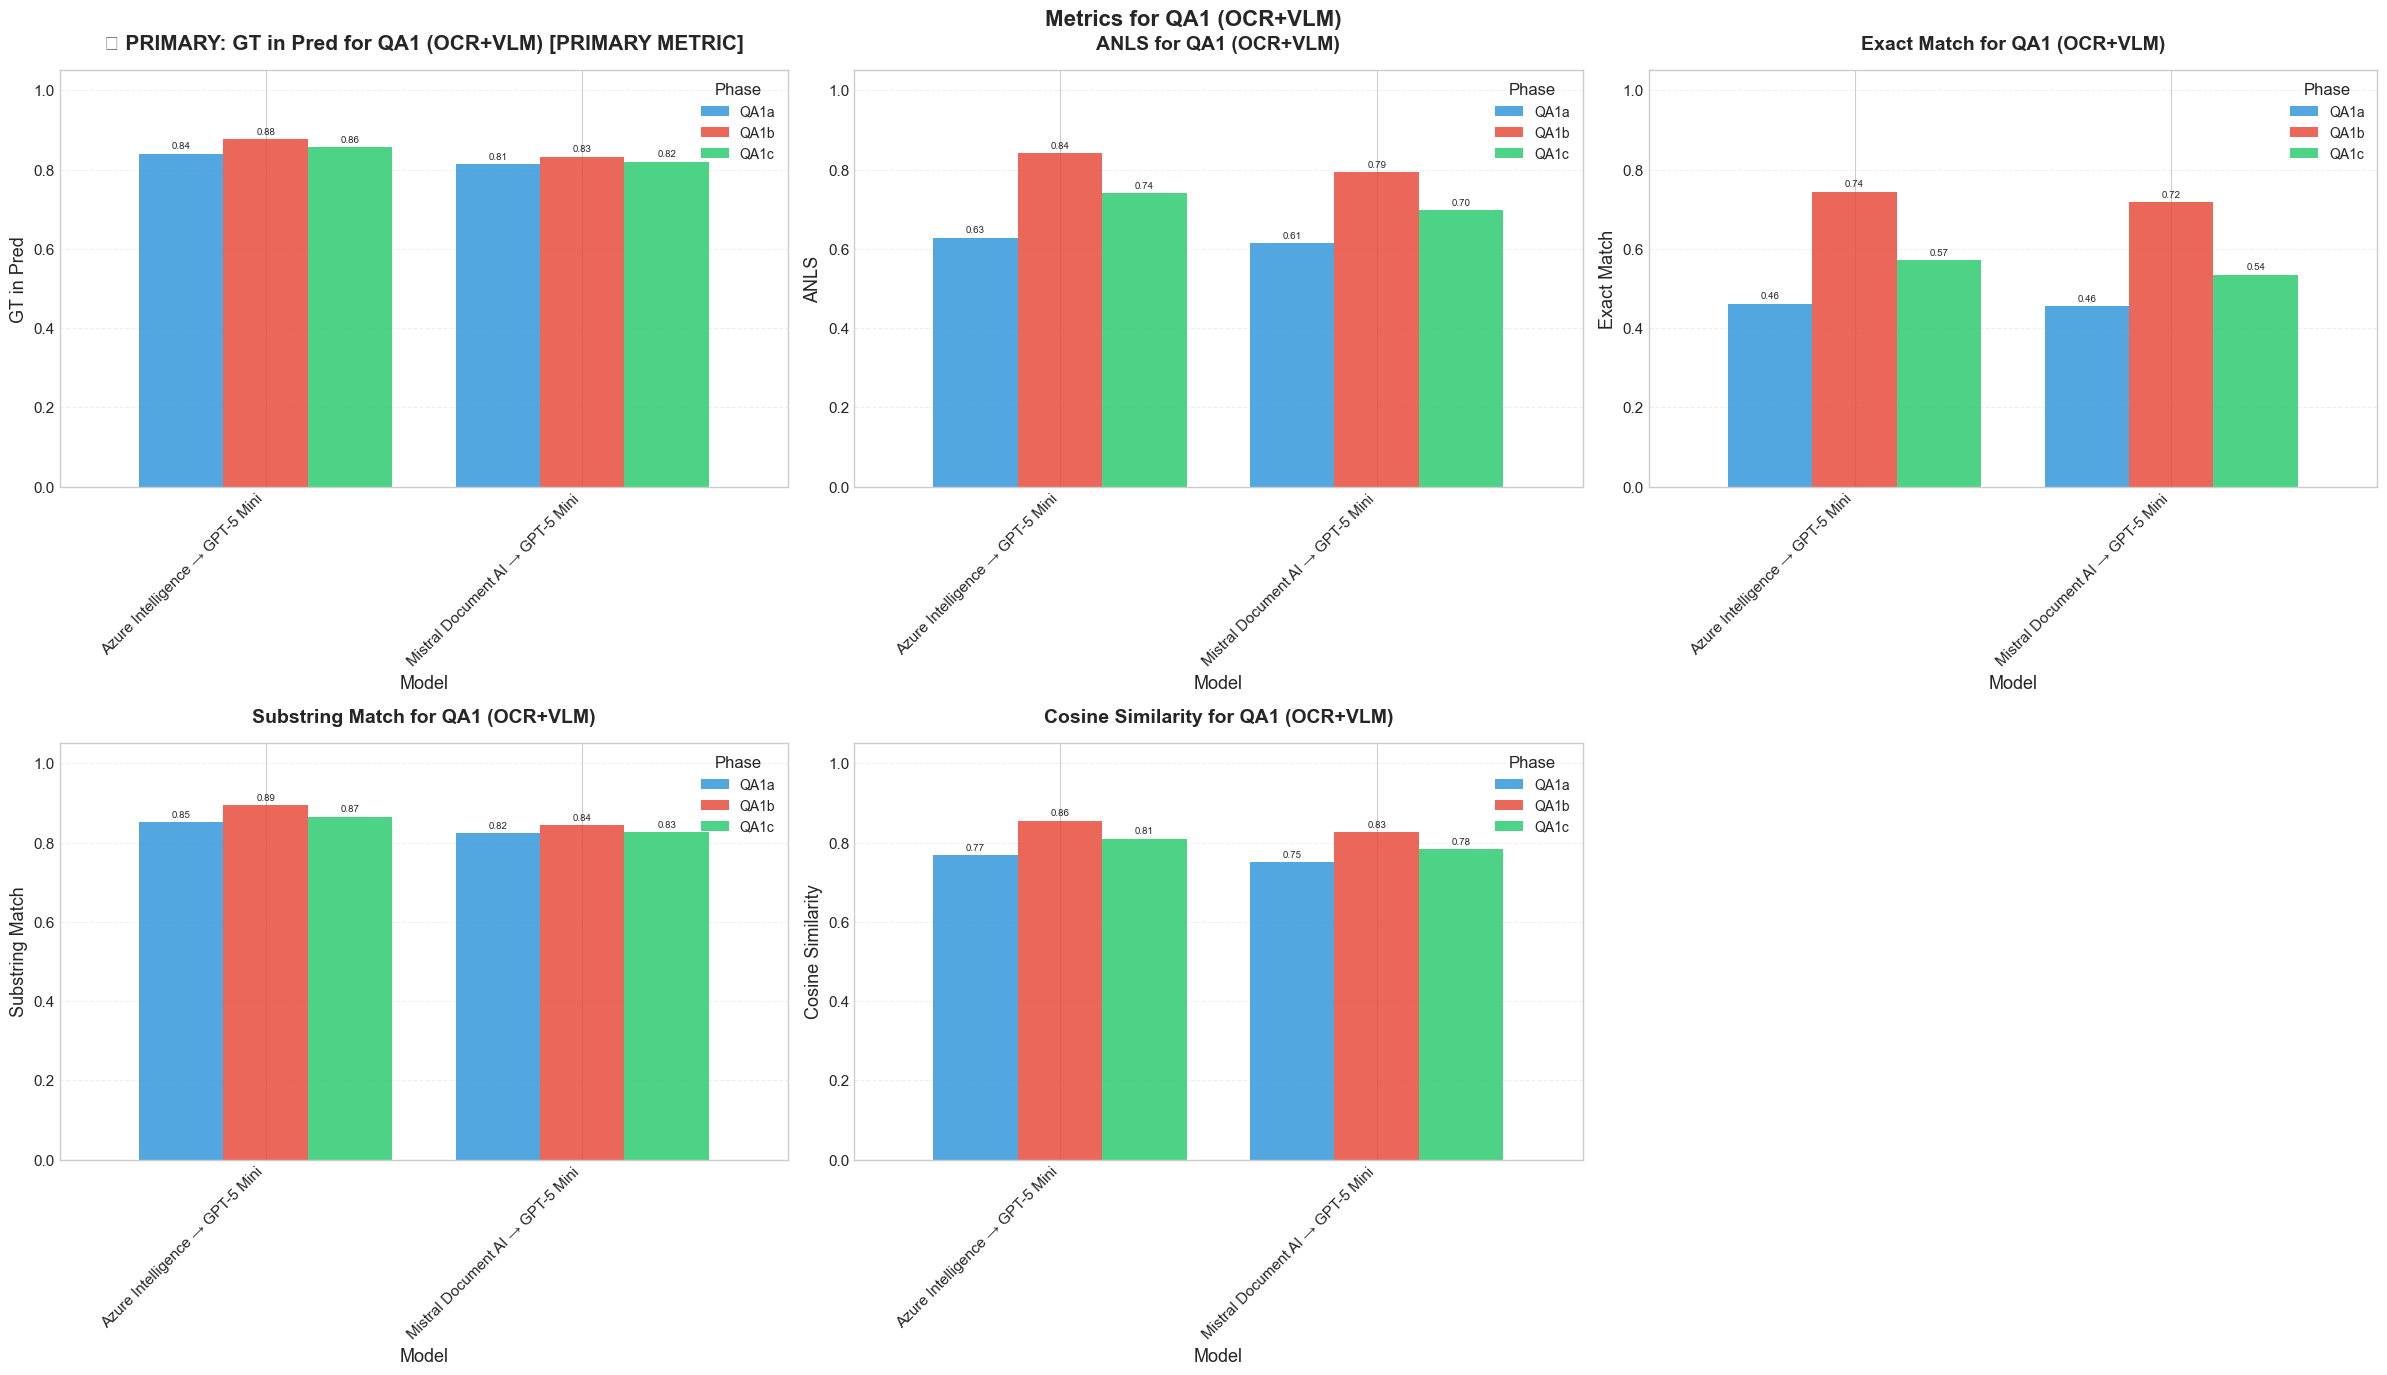

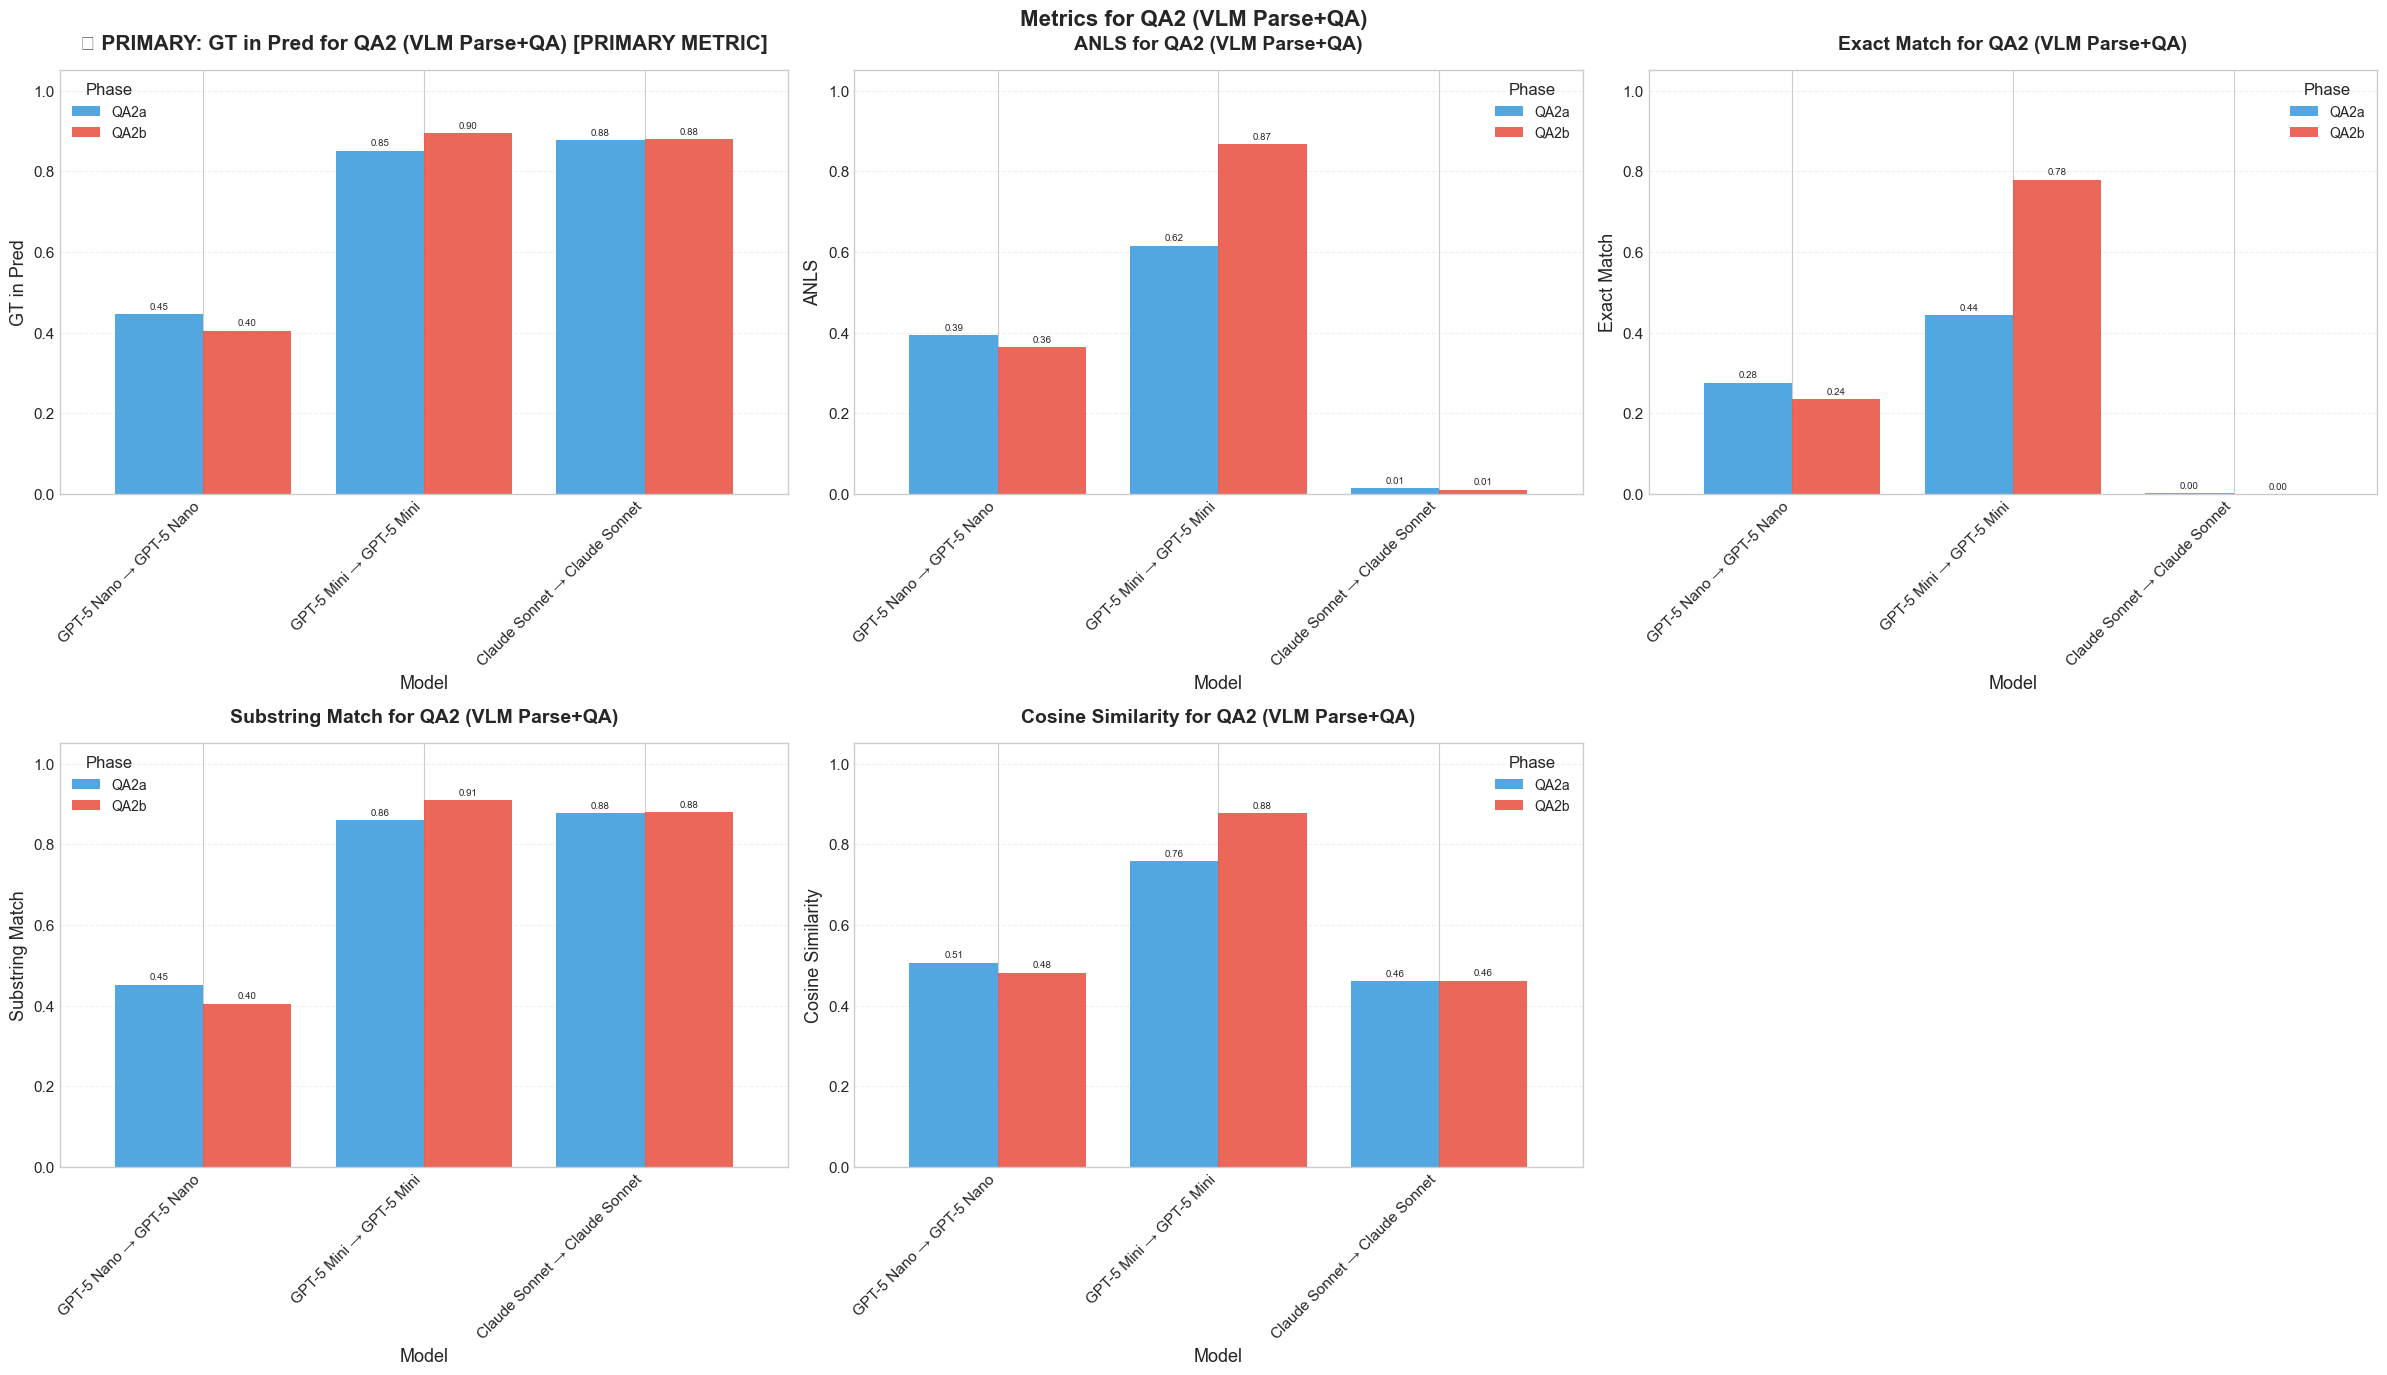

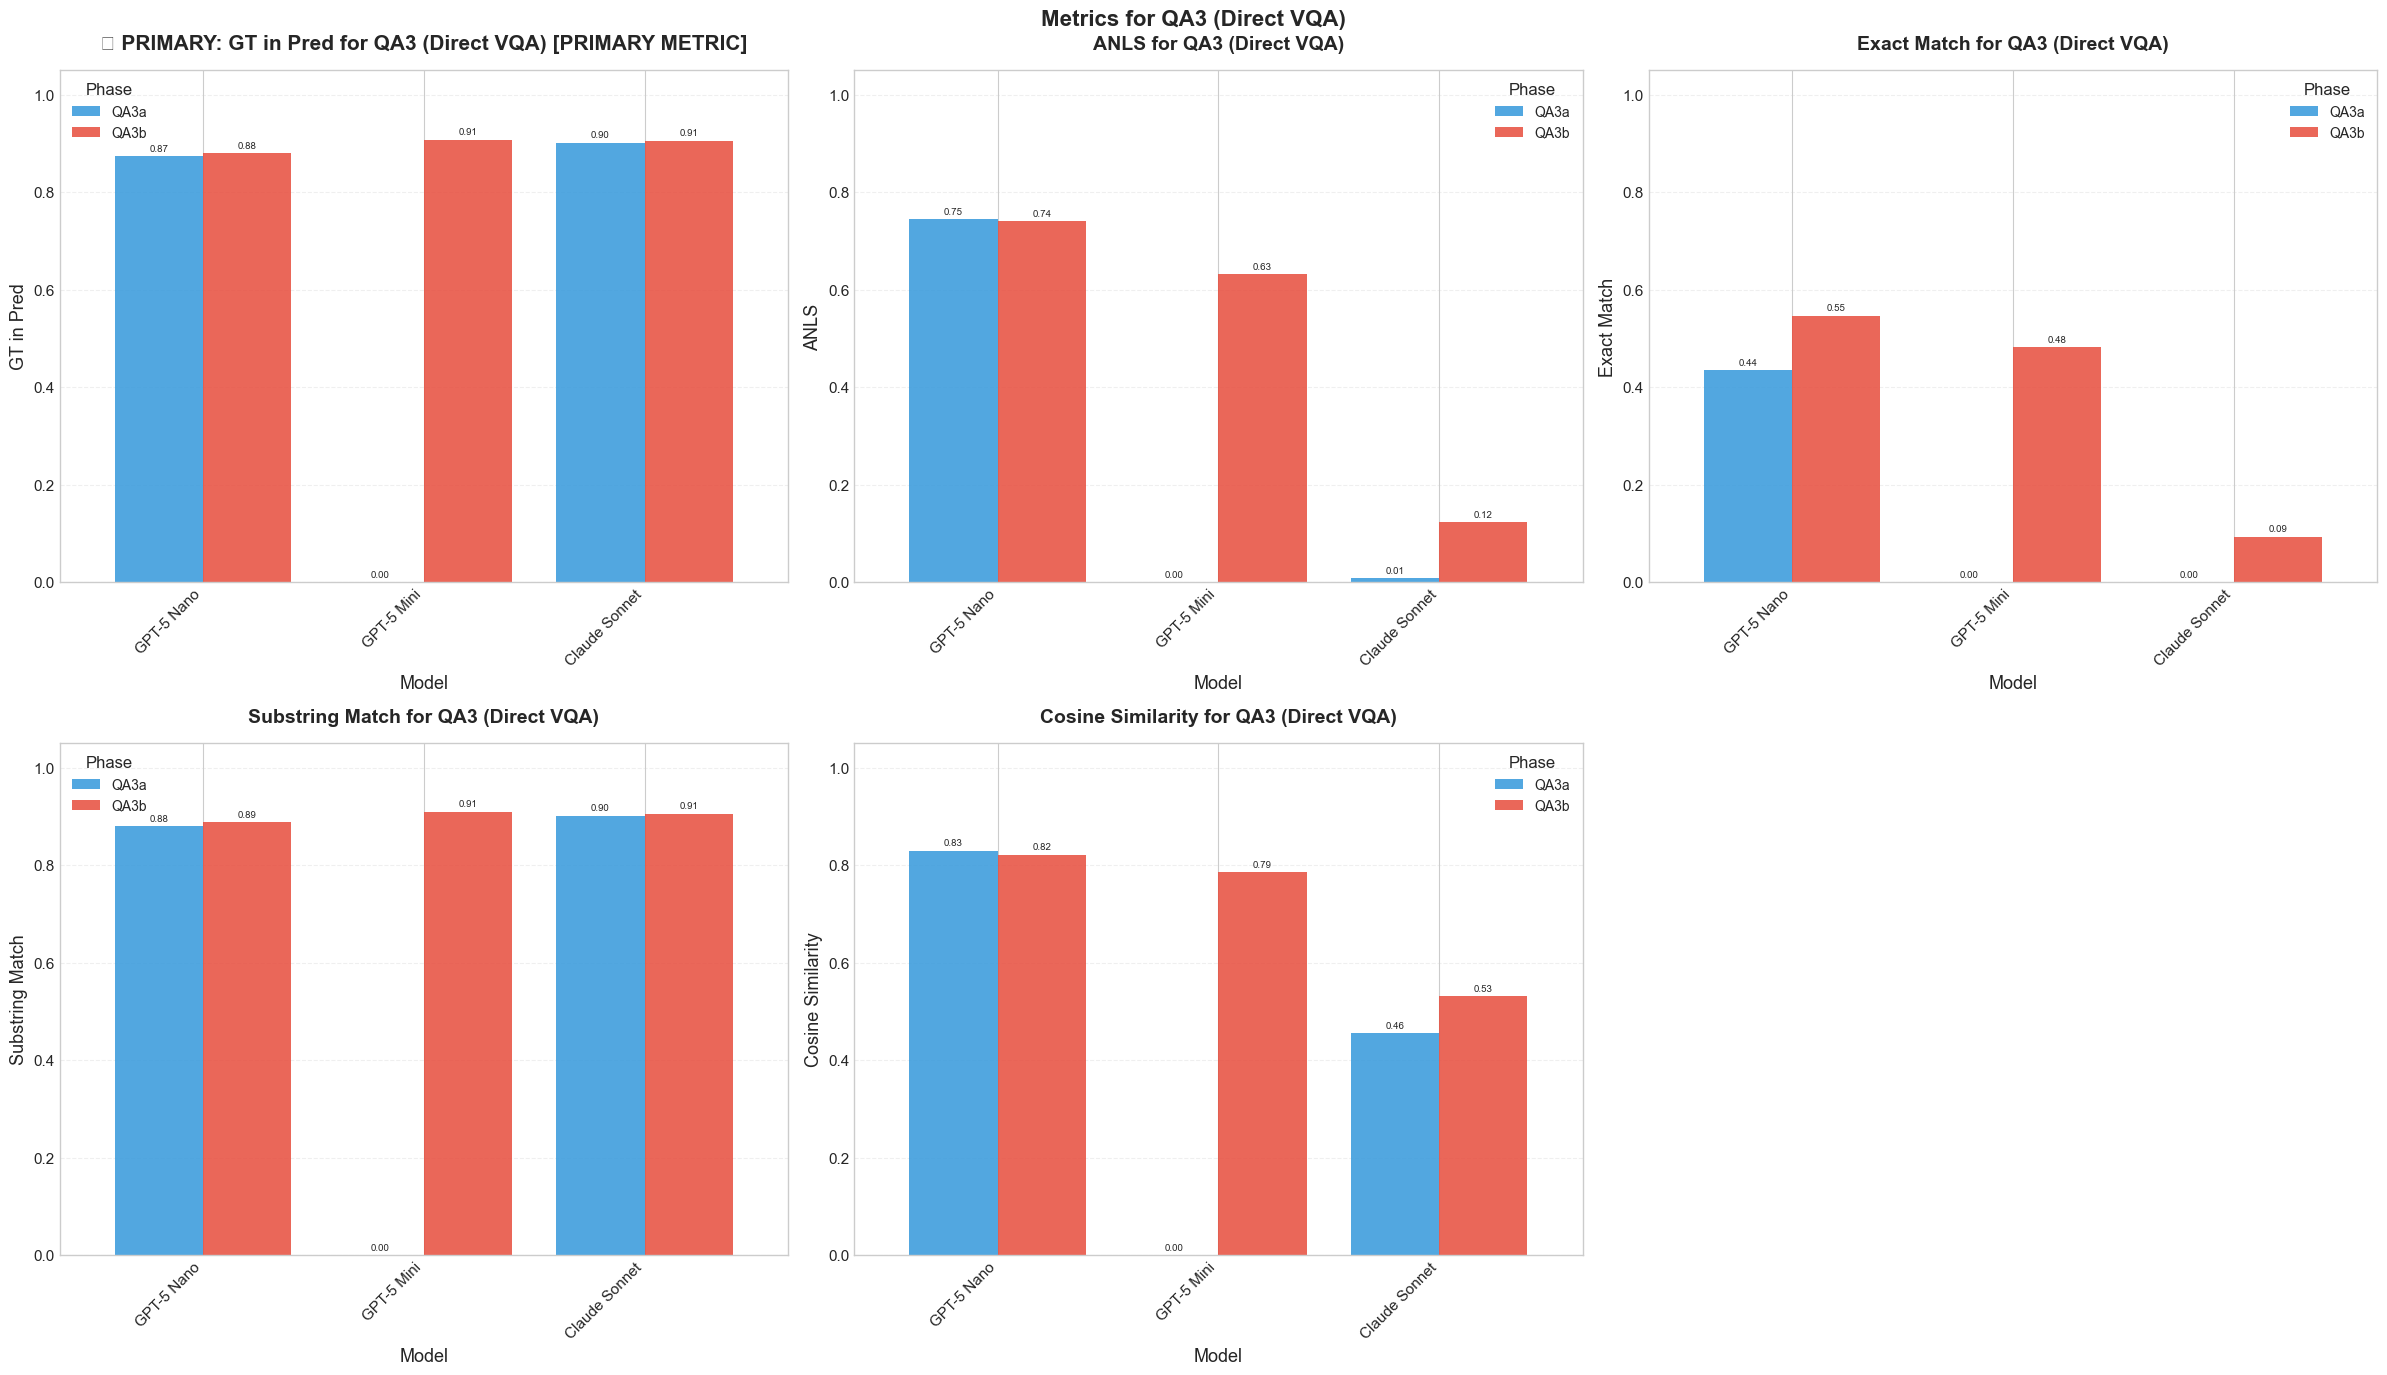


🎯 Note: 'GT in Pred' (Ground Truth in Prediction) is the PRIMARY metric


In [84]:
# Bar charts for each metric, one figure per QA strategy group
phase_groups = {
    'QA1 (OCR+VLM)': ['QA1a', 'QA1b', 'QA1c'],
    'QA2 (VLM Parse+QA)': ['QA2a', 'QA2b', 'QA2c'],
    'QA3 (Direct VQA)': ['QA3a', 'QA3b']
}

for group_name, group_phases in phase_groups.items():
    group_data = summary_df[summary_df['Phase'].isin(group_phases)]
    
    if len(group_data) == 0:
        continue
    
    # Create figure for this group
    fig, axes = plt.subplots(2, 3, figsize=(24, 14))
    axes = axes.flatten()
    
    # PRIMARY METRIC FIRST, then secondary metrics
    metrics_to_plot = ['GT in Pred', 'ANLS', 'Exact Match', 'Substring Match', 'Cosine Similarity']
    colors_palette = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22', '#95a5a6']
    
    for idx, metric in enumerate(metrics_to_plot):
        ax = axes[idx]
        
        # Pivot data for grouped bar chart (models vs phases in this group)
        pivot_data = group_data.pivot(index='Model', columns='Phase', values=metric)
        
        # Sort models
        pivot_data = pivot_data.reindex(sort_models(pivot_data.index.tolist()))
        
        pivot_data.plot(kind='bar', ax=ax, color=colors_palette[:len(pivot_data.columns)], alpha=0.85, width=0.8)
        
        # Emphasize primary metric
        title_prefix = "🎯 PRIMARY: " if metric == 'GT in Pred' else ""
        title_suffix = " [PRIMARY METRIC]" if metric == 'GT in Pred' else ""
        
        ax.set_title(f'{title_prefix}{metric} for {group_name}{title_suffix}', 
                    fontsize=15 if metric == 'GT in Pred' else 14, 
                    fontweight='bold', pad=15)
        ax.set_xlabel('Model', fontsize=13)
        ax.set_ylabel(metric, fontsize=13)
        ax.legend(title='Phase', title_fontsize=12, fontsize=10, loc='best')
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_xticklabels([get_model_display_name(m) for m in pivot_data.index], rotation=45, ha='right')
        ax.set_ylim(0, 1.05)
        
        # Add value labels on bars
        for container in ax.containers:
            ax.bar_label(container, fmt='%.2f', fontsize=7, padding=2)
    
    # Hide last subplot if not needed
    if len(metrics_to_plot) < 6:
        axes[-1].set_visible(False)
    
    plt.suptitle(f'Metrics for {group_name}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("\n🎯 Note: 'GT in Pred' (Ground Truth in Prediction) is the PRIMARY metric")

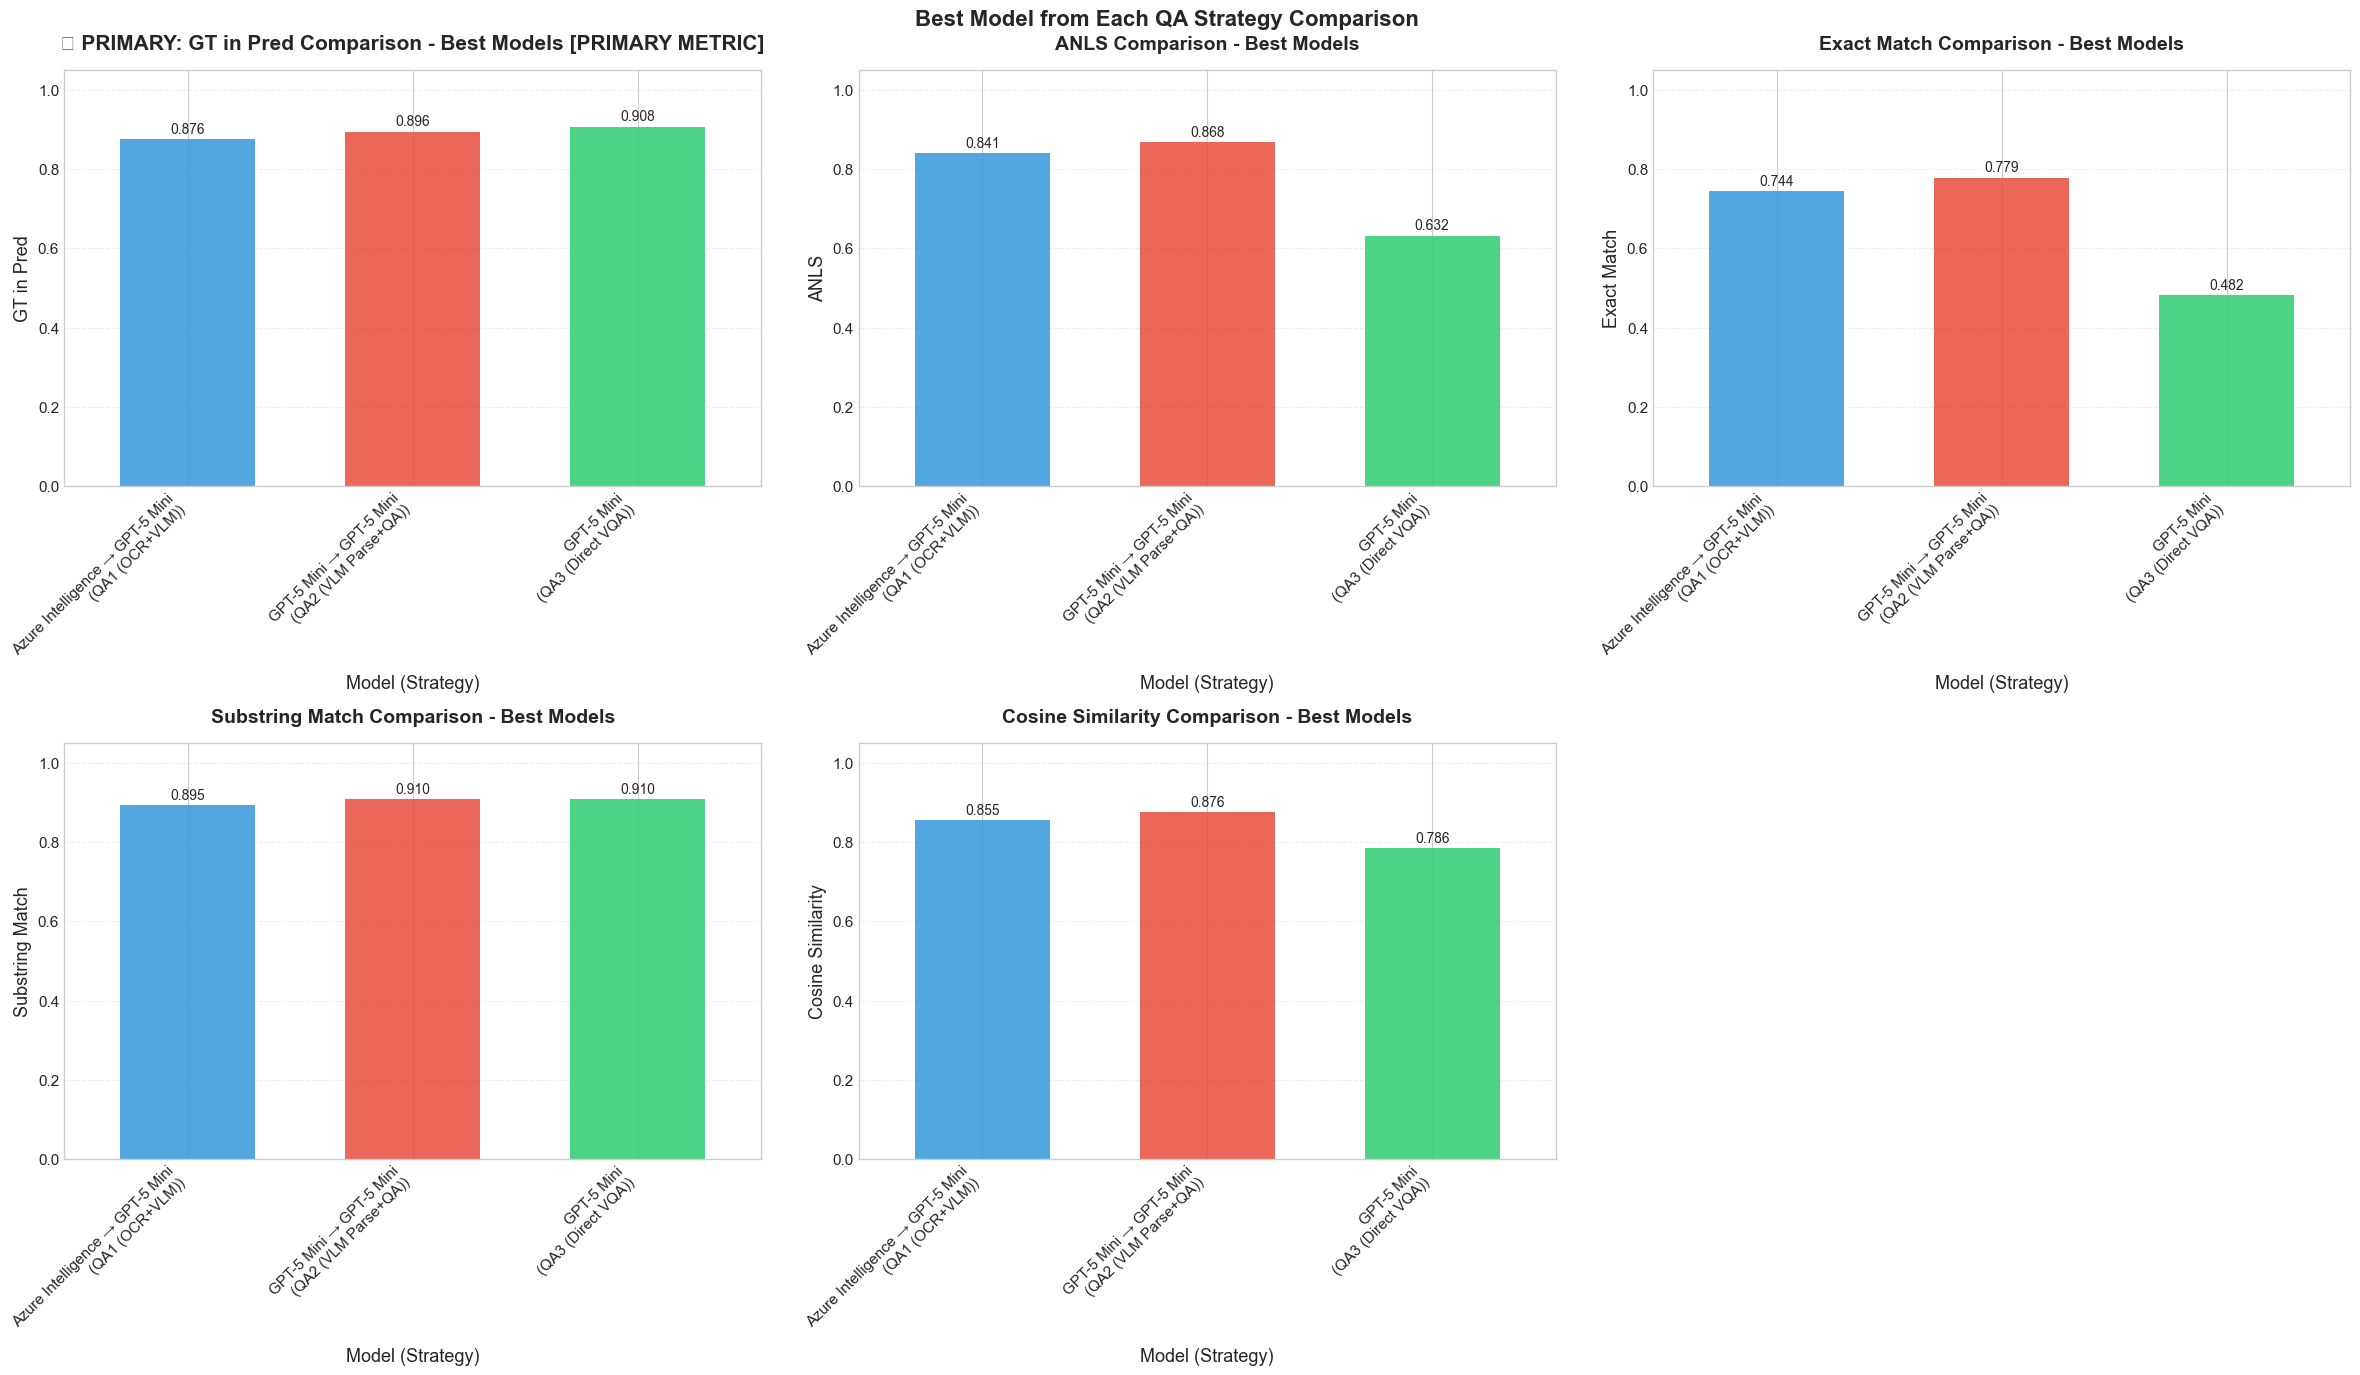


🎯 Note: 'GT in Pred' (Ground Truth in Prediction) is the PRIMARY metric
Showing best model from each strategy: QA1 (OCR+VLM), QA2 (VLM Parse+QA), QA3 (Direct VQA)


In [85]:
# Compare the best model from each QA strategy group
# Best models by GT in Pred (PRIMARY METRIC):
# - QA1: azure_intelligence__gpt-5-mini (from QA1b: GT in Pred = 0.876268)
# - QA2: gpt-5-mini__gpt-5-mini (from QA2b: GT in Pred = 0.895582) 
# - QA3: gpt-5-mini (from QA3b: GT in Pred = 0.908)

# Select the best model-phase combinations
best_models_data = summary_df.loc[
    ((summary_df['Phase'] == 'QA1b') & (summary_df['Model'] == 'azure_intelligence__gpt-5-mini')) |
    ((summary_df['Phase'] == 'QA2b') & (summary_df['Model'] == 'gpt-5-mini__gpt-5-mini')) |
    ((summary_df['Phase'] == 'QA3b') & (summary_df['Model'] == 'gpt-5-mini'))
].copy()

# Add a combined model-strategy label for display
best_models_data['Model-Strategy'] = best_models_data.apply(
    lambda row: f"{get_model_display_name(row['Model'])}\n({row['Strategy']})", axis=1
)

# Create figure for best models comparison
fig, axes = plt.subplots(2, 3, figsize=(24, 14))
axes = axes.flatten()

# PRIMARY METRIC FIRST, then secondary metrics
metrics_to_plot = ['GT in Pred', 'ANLS', 'Exact Match', 'Substring Match', 'Cosine Similarity']
colors_palette = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    
    # Pivot data for grouped bar chart (models vs metrics)
    pivot_data = best_models_data.set_index('Model-Strategy')[metric]
    
    pivot_data.plot(kind='bar', ax=ax, color=colors_palette[:len(pivot_data)], alpha=0.85, width=0.6)
    
    # Emphasize primary metric
    title_prefix = "🎯 PRIMARY: " if metric == 'GT in Pred' else ""
    title_suffix = " [PRIMARY METRIC]" if metric == 'GT in Pred' else ""
    
    ax.set_title(f'{title_prefix}{metric} Comparison - Best Models{title_suffix}', 
                fontsize=15 if metric == 'GT in Pred' else 14, 
                fontweight='bold', pad=15)
    ax.set_xlabel('Model (Strategy)', fontsize=13)
    ax.set_ylabel(metric, fontsize=13)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_ylim(0, 1.05)
    
    # Add value labels on bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=10, padding=2)

# Hide last subplot if not needed
if len(metrics_to_plot) < 6:
    axes[-1].set_visible(False)

plt.suptitle('Best Model from Each QA Strategy Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n🎯 Note: 'GT in Pred' (Ground Truth in Prediction) is the PRIMARY metric")
print("Showing best model from each strategy: QA1 (OCR+VLM), QA2 (VLM Parse+QA), QA3 (Direct VQA)")

## 7. Visualizations - Bar Charts

Compare all metrics across models and phases.

Calculating per-sample metrics for box plots (using only valid rows)...


Phase QA1a:   0%|          | 0/2 [00:00<?, ?it/s]

Identical embeddings for sample docvqa_mini_0003, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0008, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0009, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0011, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0016, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0020, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0023, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0025, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0029, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0035, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0038, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini

Phase QA1b:   0%|          | 0/2 [00:00<?, ?it/s]

Identical embeddings for sample docvqa_mini_0001, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0003, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0006, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0008, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0009, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0011, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0013, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0015, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0016, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0019, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0020, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini

...

Identical embeddings for sample docvqa_mini_0000, model gpt-5-mini__gpt-5-mini
Identical embeddings for sample docvqa_mini_0001, model gpt-5-mini__gpt-5-mini
Identical embeddings for sample docvqa_mini_0003, model gpt-5-mini__gpt-5-mini
Identical embeddings for sample docvqa_mini_0005, model gpt-5-mini__gpt-5-mini
Identical embeddings for sample docvqa_mini_0006, model gpt-5-mini__gpt-5-mini
Identical embeddings for sample docvqa_mini_0008, model gpt-5-mini__gpt-5-mini
Identical embeddings for sample docvqa_mini_0011, model gpt-5-mini__gpt-5-mini
Identical embeddings for sample docvqa_mini_0013, model gpt-5-mini__gpt-5-mini
Identical embeddings for sample docvqa_mini_0015, model gpt-5-mini__gpt-5-mini
Identical embeddings for sample docvqa_mini_0016, model gpt-5-mini__gpt-5-mini
Identical embeddings for sample docvqa_mini_0019, model gpt-5-mini__gpt-5-mini
Identical embeddings for sample docvqa_mini_0020, model gpt-5-mini__gpt-5-mini
Identical embeddings for sample docvqa_mini_0023, mo

Phase QA3a:   0%|          | 0/2 [00:00<?, ?it/s]

Identical embeddings for sample docvqa_mini_0001, model gpt-5-nano
Identical embeddings for sample docvqa_mini_0003, model gpt-5-nano
Identical embeddings for sample docvqa_mini_0008, model gpt-5-nano
Identical embeddings for sample docvqa_mini_0009, model gpt-5-nano
Identical embeddings for sample docvqa_mini_0011, model gpt-5-nano
Identical embeddings for sample docvqa_mini_0015, model gpt-5-nano
Identical embeddings for sample docvqa_mini_0016, model gpt-5-nano
Identical embeddings for sample docvqa_mini_0023, model gpt-5-nano
Identical embeddings for sample docvqa_mini_0025, model gpt-5-nano
Identical embeddings for sample docvqa_mini_0028, model gpt-5-nano
Identical embeddings for sample docvqa_mini_0029, model gpt-5-nano
Identical embeddings for sample docvqa_mini_0031, model gpt-5-nano
Identical embeddings for sample docvqa_mini_0037, model gpt-5-nano
Identical embeddings for sample docvqa_mini_0038, model gpt-5-nano
Identical embeddings for sample docvqa_mini_0040, model gpt-5-

Phase QA3b:   0%|          | 0/3 [00:00<?, ?it/s]

Identical embeddings for sample docvqa_mini_0004, model claude_sonnet
Identical embeddings for sample docvqa_mini_0023, model claude_sonnet
Identical embeddings for sample docvqa_mini_0044, model claude_sonnet
Identical embeddings for sample docvqa_mini_0061, model claude_sonnet
Identical embeddings for sample docvqa_mini_0070, model claude_sonnet
Identical embeddings for sample docvqa_mini_0106, model claude_sonnet
Identical embeddings for sample docvqa_mini_0208, model claude_sonnet
Identical embeddings for sample docvqa_mini_0249, model claude_sonnet
Identical embeddings for sample docvqa_mini_0267, model claude_sonnet
Identical embeddings for sample docvqa_mini_0281, model claude_sonnet
Identical embeddings for sample docvqa_mini_0291, model claude_sonnet
Identical embeddings for sample docvqa_mini_0299, model claude_sonnet
Identical embeddings for sample docvqa_mini_0311, model claude_sonnet
Identical embeddings for sample docvqa_mini_0321, model claude_sonnet
Identical embeddings

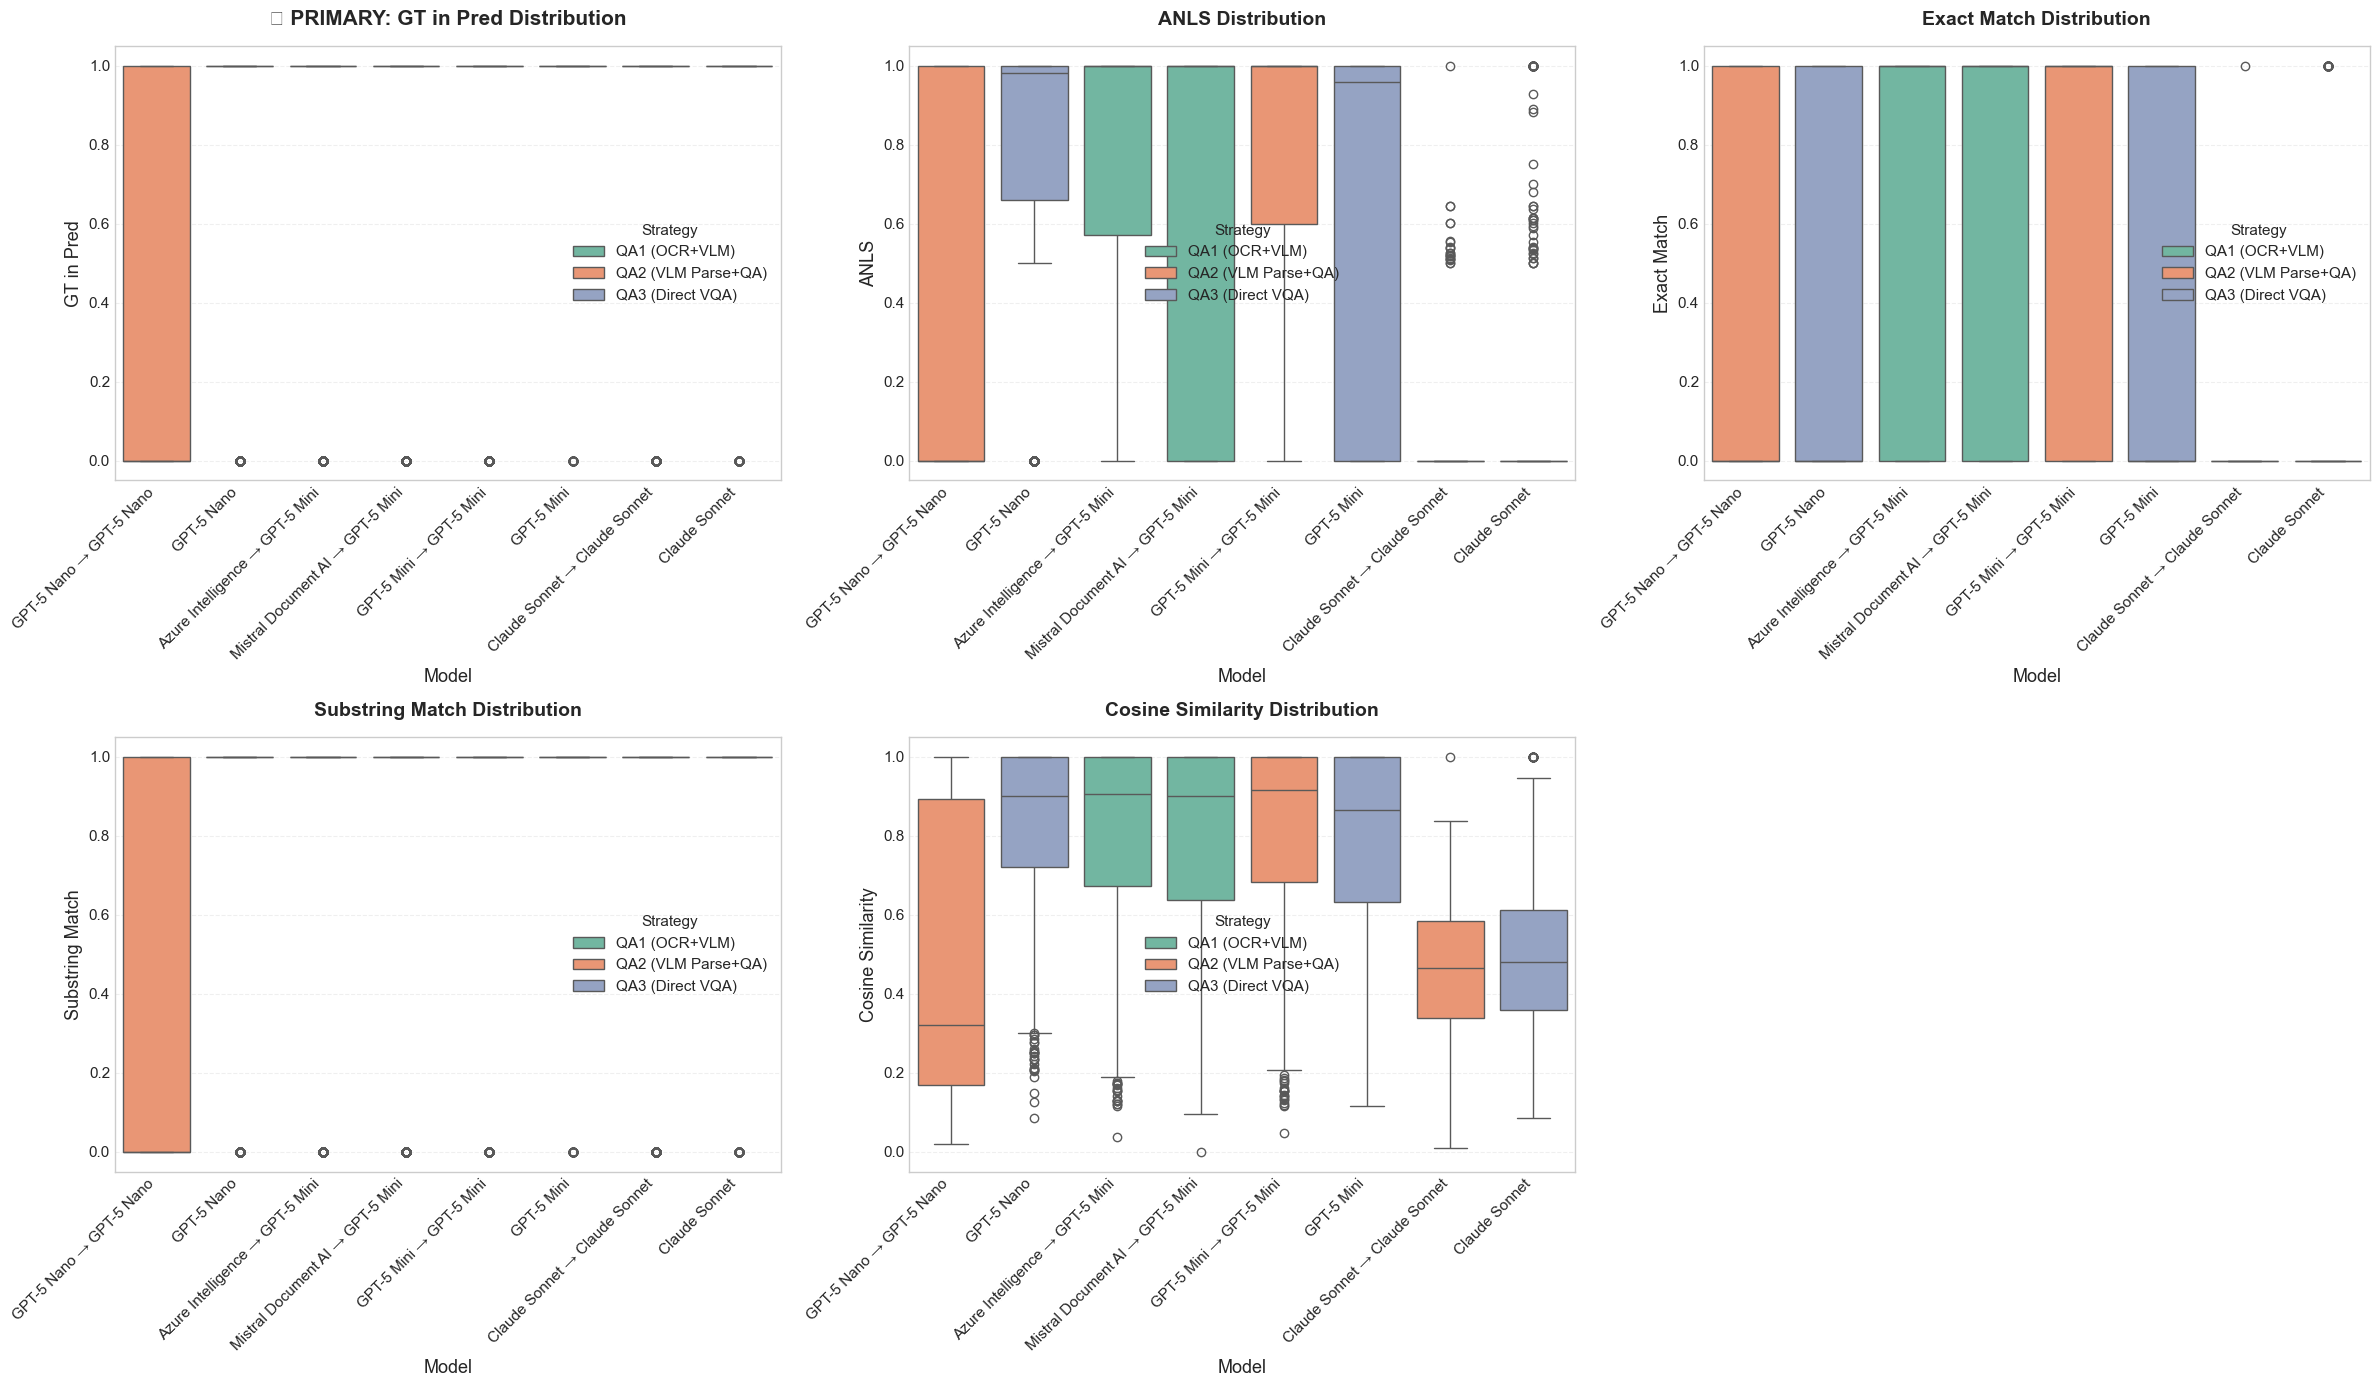


🎯 Note: Distributions show only valid samples (empty/error rows excluded)


In [86]:
# Calculate per-sample metrics for box plots
sample_metrics_data = []

print("Calculating per-sample metrics for box plots (using only valid rows)...")
for phase, df in phase_dfs.items():
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    for pred_col in tqdm(pred_cols, desc=f"Phase {phase}", leave=False):
        model = pred_col.replace('prediction_', '')
        err_col = f'error_{model}'
        
        # Filter to only valid rows
        for _, row in df.iterrows():
            if not is_valid_row(row, pred_col, err_col):
                continue  # Skip invalid rows
            
            ground_truths = parse_ground_truths(row['ground_truths'])
            metrics = calculate_qa_metrics(
                row[pred_col], ground_truths, phase, 
                row['sample_id'], model, embedding_manager
            )
            
            sample_metrics_data.append({
                'Phase': phase,
                'Model': model,
                'GT in Pred': metrics['gt_in_pred'],  # PRIMARY METRIC
                'ANLS': metrics['anls'],
                'Exact Match': metrics['exact_match'],
                'Substring Match': metrics['substring_match'],
                'Cosine Similarity': metrics['cosine_similarity']
            })

sample_metrics_df = pd.DataFrame(sample_metrics_data)

# Add strategy column for grouping
sample_metrics_df['Strategy'] = sample_metrics_df['Phase'].apply(get_phase_strategy)

# Create box plots (PRIMARY METRIC FIRST)
fig, axes = plt.subplots(2, 3, figsize=(24, 14))
axes = axes.flatten()

metrics_for_boxplot = ['GT in Pred', 'ANLS', 'Exact Match', 'Substring Match', 'Cosine Similarity']

for idx, metric in enumerate(metrics_for_boxplot):
    ax = axes[idx]
    
    # Create box plot
    sample_metrics_df_sorted = sample_metrics_df.copy()
    sample_metrics_df_sorted['Model'] = pd.Categorical(
        sample_metrics_df_sorted['Model'],
        categories=sort_models(sample_metrics_df_sorted['Model'].unique().tolist()),
        ordered=True
    )
    
    sns.boxplot(data=sample_metrics_df_sorted, x='Model', y=metric, hue='Strategy', ax=ax, palette='Set2')
    
    # Emphasize primary metric
    title_prefix = "🎯 PRIMARY: " if metric == 'GT in Pred' else ""
    ax.set_title(f'{title_prefix}{metric} Distribution', 
                fontsize=15 if metric == 'GT in Pred' else 14, 
                fontweight='bold', pad=15)
    ax.set_xlabel('Model', fontsize=13)
    ax.set_ylabel(metric, fontsize=13)
    ax.set_xticklabels([get_model_display_name(t.get_text()) for t in ax.get_xticklabels()], rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.legend(title='Strategy', loc='best')

# Hide last subplot if not needed
if len(metrics_for_boxplot) < 6:
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

print("\n🎯 Note: Distributions show only valid samples (empty/error rows excluded)")

## 8. Visualizations - Box Plots

Distribution analysis showing variance and outliers.

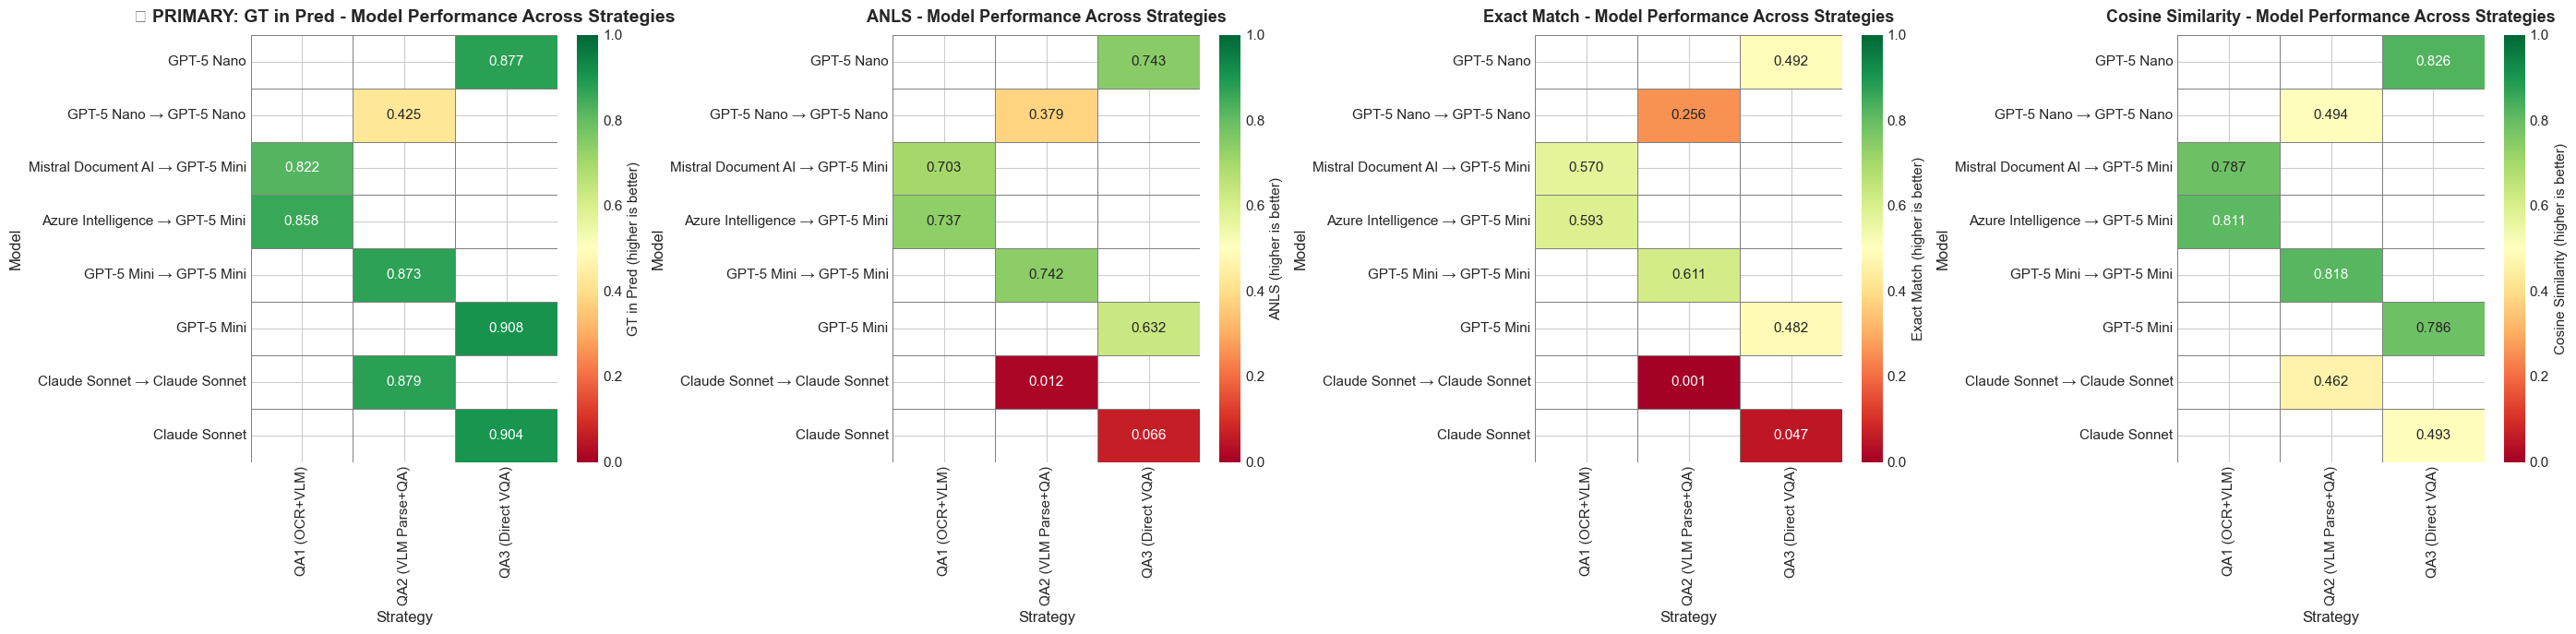


🎯 Note: 'GT in Pred' heatmap shows PRIMARY metric performance


In [87]:
# Create heatmaps for key metrics (PRIMARY METRIC FIRST)
metrics_to_show = ['GT in Pred', 'ANLS', 'Exact Match', 'Cosine Similarity']
fig, axes = plt.subplots(1, len(metrics_to_show), figsize=(7 * len(metrics_to_show), 7))

if len(metrics_to_show) == 1:
    axes = [axes]

for idx, metric_name in enumerate(metrics_to_show):
    ax = axes[idx]
    
    # Create heatmap data: rows = models, columns = strategies
    heatmap_data = []
    model_names = []
    strategy_names = ['QA1 (OCR+VLM)', 'QA2 (VLM Parse+QA)', 'QA3 (Direct VQA)']
    
    # Get all unique models across all phases and sort them
    all_models = set()
    for phase_models in metrics_results.values():
        all_models.update(phase_models.keys())
    all_models = sort_models(list(all_models))
    
    # Build heatmap data aggregated by strategy
    for model in all_models:
        row_data = []
        for strategy in strategy_names:
            # Get phases for this strategy
            strategy_phases = [p for p in metrics_results.keys() if get_phase_strategy(p) == strategy]
            values = []
            for phase in strategy_phases:
                if model in metrics_results[phase]:
                    metric_key = metric_name.lower().replace(' ', '_')
                    value = metrics_results[phase][model].get(metric_key, np.nan)
                    if not np.isnan(value):
                        values.append(value)
            # Average across phases in strategy
            avg_value = np.mean(values) if values else np.nan
            row_data.append(avg_value)
        
        heatmap_data.append(row_data)
        model_names.append(model)
    
    heatmap_df = pd.DataFrame(
        heatmap_data,
        index=[get_model_display_name(m) for m in model_names],
        columns=strategy_names
    )
    
    # Use colormap: green for good, red for bad (all QA metrics: higher is better)
    cmap = 'RdYlGn'
    cbar_label = f'{metric_name} (higher is better)'
    
    sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap=cmap, 
                ax=ax, cbar_kws={'label': cbar_label}, 
                vmin=0, vmax=1, linewidths=0.5, linecolor='gray')
    
    # Emphasize primary metric in title
    title_prefix = "🎯 PRIMARY: " if metric_name == 'GT in Pred' else ""
    ax.set_title(f'{title_prefix}{metric_name} - Model Performance Across Strategies', 
                fontsize=14 if metric_name == 'GT in Pred' else 13, 
                fontweight='bold', pad=10)
    ax.set_xlabel('Strategy', fontsize=12)
    ax.set_ylabel('Model', fontsize=12)

plt.tight_layout()
plt.show()

print("\n🎯 Note: 'GT in Pred' heatmap shows PRIMARY metric performance")

## 9. Visualizations - Heatmaps

Model × Strategy performance heatmaps.

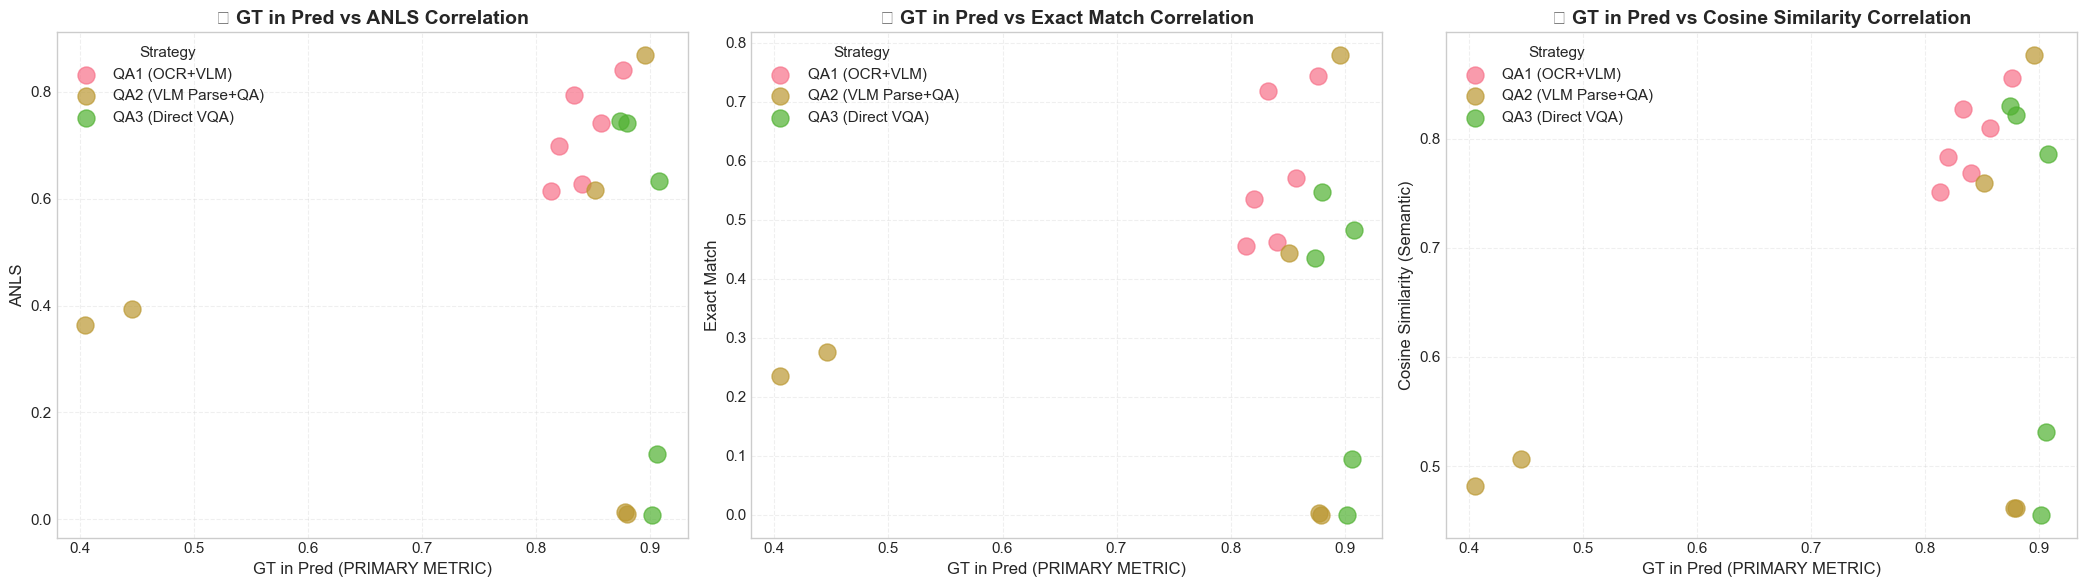


🎯 Note: All correlations are shown against the PRIMARY metric (GT in Pred)


In [88]:
# Scatter plots: GT in Pred (PRIMARY) vs other metrics
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# GT in Pred vs ANLS
ax1 = axes[0]
for strategy in summary_df['Strategy'].unique():
    strategy_data = summary_df[summary_df['Strategy'] == strategy]
    ax1.scatter(strategy_data['GT in Pred'], strategy_data['ANLS'], 
               s=150, alpha=0.7, label=strategy)

ax1.set_title('🎯 GT in Pred vs ANLS Correlation', fontsize=14, fontweight='bold')
ax1.set_xlabel('GT in Pred (PRIMARY METRIC)', fontsize=12)
ax1.set_ylabel('ANLS', fontsize=12)
ax1.legend(title='Strategy', loc='best')
ax1.grid(alpha=0.3, linestyle='--')

# GT in Pred vs Exact Match
ax2 = axes[1]
for strategy in summary_df['Strategy'].unique():
    strategy_data = summary_df[summary_df['Strategy'] == strategy]
    ax2.scatter(strategy_data['GT in Pred'], strategy_data['Exact Match'], 
               s=150, alpha=0.7, label=strategy)

ax2.set_title('🎯 GT in Pred vs Exact Match Correlation', fontsize=14, fontweight='bold')
ax2.set_xlabel('GT in Pred (PRIMARY METRIC)', fontsize=12)
ax2.set_ylabel('Exact Match', fontsize=12)
ax2.legend(title='Strategy', loc='best')
ax2.grid(alpha=0.3, linestyle='--')

# GT in Pred vs Cosine Similarity
ax3 = axes[2]
for strategy in summary_df['Strategy'].unique():
    strategy_data = summary_df[summary_df['Strategy'] == strategy]
    ax3.scatter(strategy_data['GT in Pred'], strategy_data['Cosine Similarity'], 
               s=150, alpha=0.7, label=strategy)

ax3.set_title('🎯 GT in Pred vs Cosine Similarity Correlation', fontsize=14, fontweight='bold')
ax3.set_xlabel('GT in Pred (PRIMARY METRIC)', fontsize=12)
ax3.set_ylabel('Cosine Similarity (Semantic)', fontsize=12)
ax3.legend(title='Strategy', loc='best')
ax3.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("\n🎯 Note: All correlations are shown against the PRIMARY metric (GT in Pred)")

## 10. Visualizations - Scatter Plots

Correlation analysis between metrics.

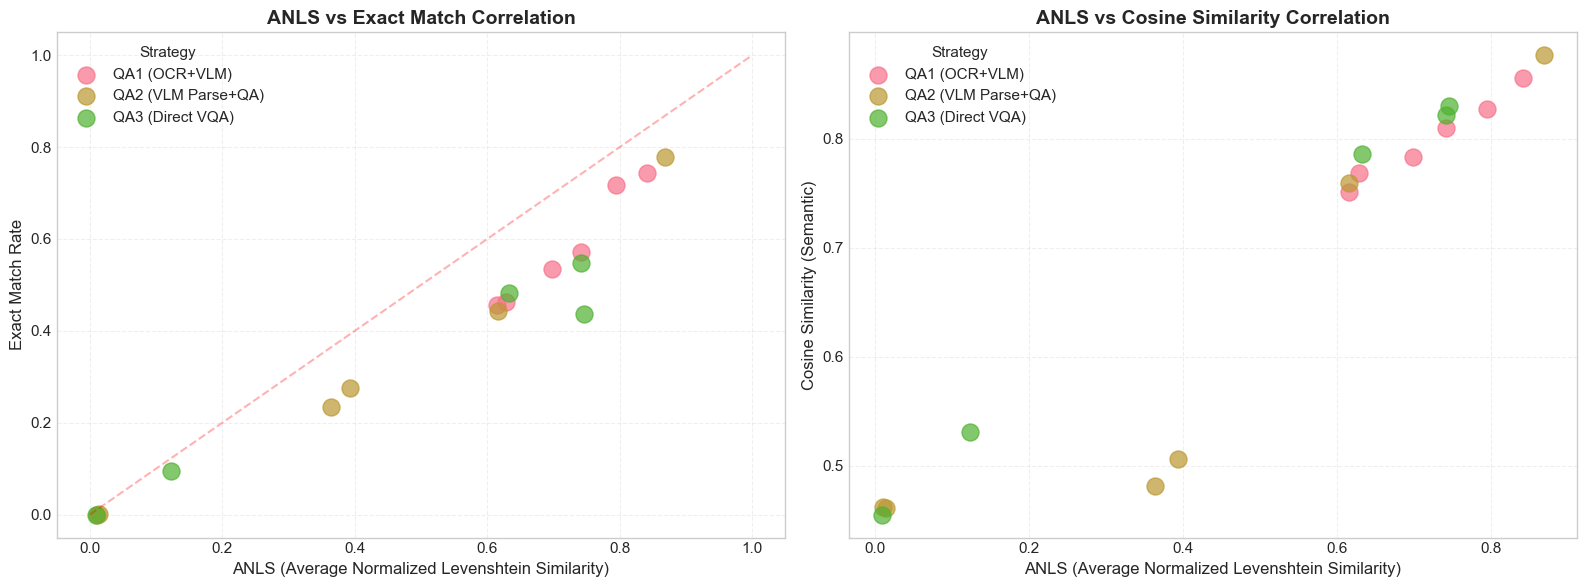

In [89]:
# Scatter plots: ANLS vs other metrics
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ANLS vs Exact Match
ax1 = axes[0]
for strategy in summary_df['Strategy'].unique():
    strategy_data = summary_df[summary_df['Strategy'] == strategy]
    ax1.scatter(strategy_data['ANLS'], strategy_data['Exact Match'], 
               s=150, alpha=0.7, label=strategy)

ax1.set_title('ANLS vs Exact Match Correlation', fontsize=14, fontweight='bold')
ax1.set_xlabel('ANLS (Average Normalized Levenshtein Similarity)', fontsize=12)
ax1.set_ylabel('Exact Match Rate', fontsize=12)
ax1.legend(title='Strategy', loc='best')
ax1.grid(alpha=0.3, linestyle='--')
ax1.plot([0, 1], [0, 1], 'r--', alpha=0.3, label='ANLS=EM')

# ANLS vs Cosine Similarity
ax2 = axes[1]
for strategy in summary_df['Strategy'].unique():
    strategy_data = summary_df[summary_df['Strategy'] == strategy]
    ax2.scatter(strategy_data['ANLS'], strategy_data['Cosine Similarity'], 
               s=150, alpha=0.7, label=strategy)

ax2.set_title('ANLS vs Cosine Similarity Correlation', fontsize=14, fontweight='bold')
ax2.set_xlabel('ANLS (Average Normalized Levenshtein Similarity)', fontsize=12)
ax2.set_ylabel('Cosine Similarity (Semantic)', fontsize=12)
ax2.legend(title='Strategy', loc='best')
ax2.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

## 11. QA-Specific Analysis

Analyze question types, answer lengths, and QA-specific patterns.


Question Type Distribution (QA1a):
  What           :  321 questions ( 64.2%)
  How            :   44 questions (  8.8%)
  Who            :   40 questions (  8.0%)
  Other          :   39 questions (  7.8%)
  Which          :   33 questions (  6.6%)
  When           :    8 questions (  1.6%)
  Where          :    8 questions (  1.6%)
  Yes/No         :    6 questions (  1.2%)
  Why            :    1 questions (  0.2%)


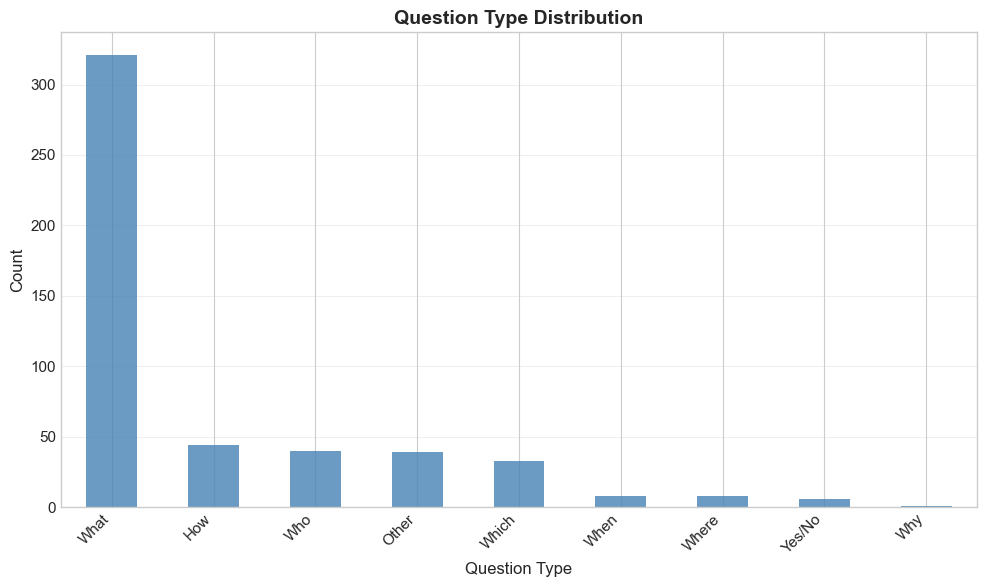

In [90]:
# Question type analysis
if len(phase_dfs) > 0:
    # Use first available phase for analysis
    analysis_phase = list(phase_dfs.keys())[0]
    df_analysis = phase_dfs[analysis_phase].copy()
    
    # Add question type categorization
    df_analysis['question_type'] = df_analysis['question'].apply(categorize_question_type)
    
    print(f"\nQuestion Type Distribution ({analysis_phase}):")
    print("=" * 80)
    type_counts = df_analysis['question_type'].value_counts()
    for qtype, count in type_counts.items():
        pct = count / len(df_analysis) * 100
        print(f"  {qtype:15s}: {count:4d} questions ({pct:5.1f}%)")
    
    # Visualize question types
    fig, ax = plt.subplots(figsize=(10, 6))
    type_counts.plot(kind='bar', ax=ax, color='steelblue', alpha=0.8)
    ax.set_title('Question Type Distribution', fontsize=14, fontweight='bold')
    ax.set_xlabel('Question Type', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

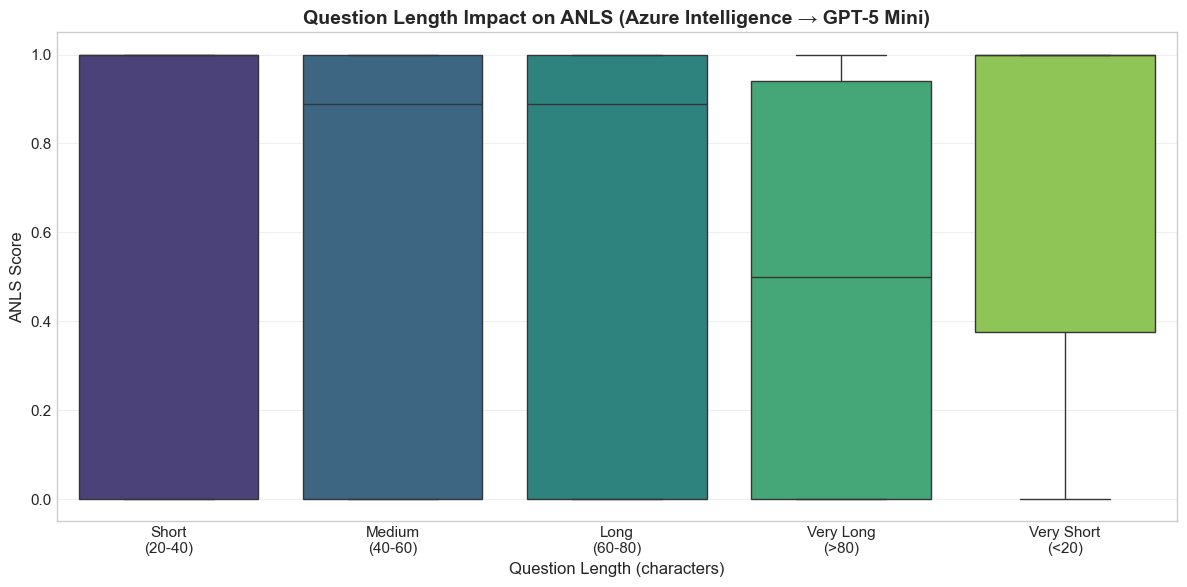

In [91]:
# Question length impact on performance
if len(phase_dfs) > 0:
    df_analysis['question_length'] = df_analysis['question'].astype(str).str.len()
    df_analysis['question_length_bin'] = pd.cut(
        df_analysis['question_length'],
        bins=[0, 20, 40, 60, 80, 1000],
        labels=['Very Short\n(<20)', 'Short\n(20-40)', 'Medium\n(40-60)', 'Long\n(60-80)', 'Very Long\n(>80)']
    )
    
    # Calculate ANLS for first model per length bin
    pred_col = [col for col in df_analysis.columns if col.startswith('prediction_')][0]
    model_name = pred_col.replace('prediction_', '')
    
    anls_by_length = []
    for _, row in df_analysis.iterrows():
        ground_truths = parse_ground_truths(row['ground_truths'])
        anls = compute_anls(str(row[pred_col]), ground_truths, threshold=0.5)
        anls_by_length.append({
            'question_length_bin': row['question_length_bin'],
            'anls': anls
        })
    
    anls_length_df = pd.DataFrame(anls_by_length)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.boxplot(data=anls_length_df, x='question_length_bin', y='anls', ax=ax, palette='viridis')
    ax.set_title(f'Question Length Impact on ANLS ({get_model_display_name(model_name)})', 
                fontsize=14, fontweight='bold')
    ax.set_xlabel('Question Length (characters)', fontsize=12)
    ax.set_ylabel('ANLS Score', fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


🎯 PHASE STRATEGY COMPARISON (PRIMARY METRIC: GT in Pred)

QA1 (OCR+VLM):
  🎯 Mean GT in Pred: 0.8401 [PRIMARY]
     Mean ANLS: 0.7196
     Mean Exact Match: 0.5813
     Mean Substring Match: 0.8506
  Phases included: QA1a, QA1b, QA1c

QA2 (VLM Parse+QA):
  🎯 Mean GT in Pred: 0.7258 [PRIMARY]
     Mean ANLS: 0.3778
     Mean Exact Match: 0.2894
     Mean Substring Match: 0.7305
  Phases included: QA2a, QA2b, QA2c

QA3 (Direct VQA):
  🎯 Mean GT in Pred: 0.8940 [PRIMARY]
     Mean ANLS: 0.4502
     Mean Exact Match: 0.3118
     Mean Substring Match: 0.8972
  Phases included: QA3a, QA3b


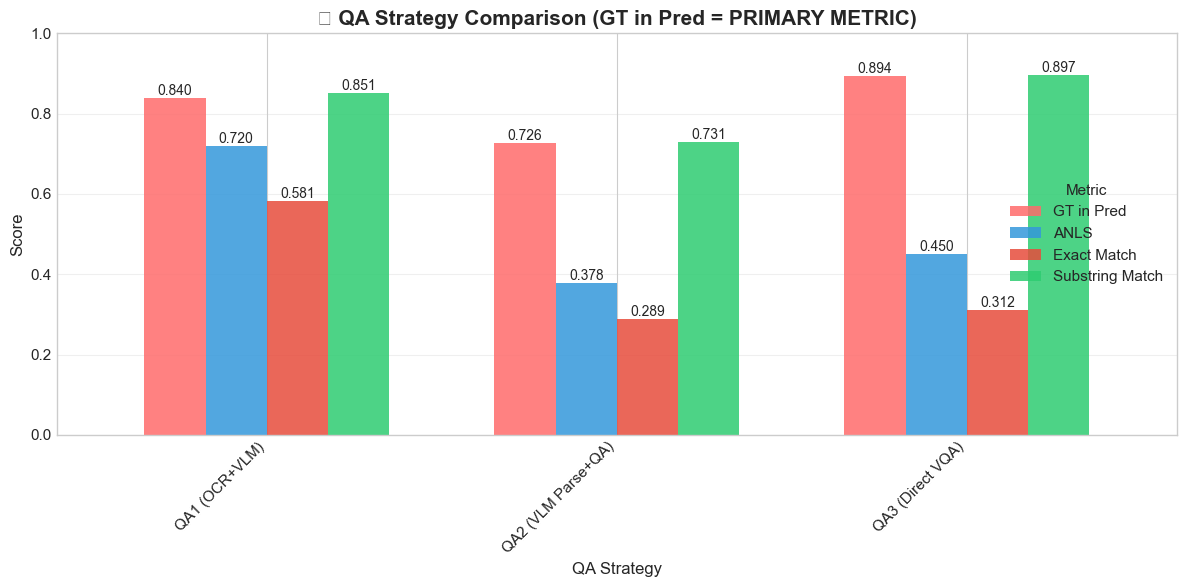


🏆 BEST STRATEGY (by GT in Pred - PRIMARY METRIC):
  QA3 (Direct VQA): GT in Pred = 0.8940


In [92]:
# Group phases by strategy
phase_groups = {
    'QA1 (OCR+VLM)': ['QA1a', 'QA1b', 'QA1c'],
    'QA2 (VLM Parse+QA)': ['QA2a', 'QA2b', 'QA2c'],
    'QA3 (Direct VQA)': ['QA3a', 'QA3b']
}

print("\n" + "=" * 120)
print("🎯 PHASE STRATEGY COMPARISON (PRIMARY METRIC: GT in Pred)")
print("=" * 120)

strategy_results = []
for group_name, phases in phase_groups.items():
    group_data = summary_df[summary_df['Phase'].isin(phases)]
    if len(group_data) > 0:
        avg_gt_in_pred = group_data['GT in Pred'].mean()
        avg_anls = group_data['ANLS'].mean()
        avg_em = group_data['Exact Match'].mean()
        avg_substring = group_data['Substring Match'].mean()
        
        print(f"\n{group_name}:")
        print(f"  🎯 Mean GT in Pred: {avg_gt_in_pred:.4f} [PRIMARY]")
        print(f"     Mean ANLS: {avg_anls:.4f}")
        print(f"     Mean Exact Match: {avg_em:.4f}")
        print(f"     Mean Substring Match: {avg_substring:.4f}")
        print(f"  Phases included: {', '.join(phases)}")
        
        strategy_results.append({
            'Strategy': group_name,
            'GT in Pred': avg_gt_in_pred,  # PRIMARY FIRST
            'ANLS': avg_anls,
            'Exact Match': avg_em,
            'Substring Match': avg_substring
        })

# Visualize strategy comparison (PRIMARY METRIC FIRST)
if strategy_results:
    strategy_df = pd.DataFrame(strategy_results)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    strategy_df.set_index('Strategy')[['GT in Pred', 'ANLS', 'Exact Match', 'Substring Match']].plot(
        kind='bar', ax=ax, color=['#FF6B6B', '#3498db', '#e74c3c', '#2ecc71'], alpha=0.85, width=0.7
    )
    ax.set_title('🎯 QA Strategy Comparison (GT in Pred = PRIMARY METRIC)', fontsize=15, fontweight='bold')
    ax.set_xlabel('QA Strategy', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.legend(title='Metric', loc='best', fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_ylim(0, 1.0)
    
    # Add value labels
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "=" * 120)
    print("🏆 BEST STRATEGY (by GT in Pred - PRIMARY METRIC):")
    best_strategy = strategy_df.loc[strategy_df['GT in Pred'].idxmax()]
    print(f"  {best_strategy['Strategy']}: GT in Pred = {best_strategy['GT in Pred']:.4f}")
    print("=" * 120)

## 12. Phase Comparison Analysis

Compare the three QA strategies: OCR+VLM, VLM Parse+QA, and Direct VQA.


Phase Strategy Comparison:

QA1 (OCR+VLM):
  🎯 Mean GT in Pred: 0.8401 [PRIMARY]
     Mean ANLS: 0.7196
     Mean Exact Match: 0.5813
     Mean Substring Match: 0.8506
  Phases included: QA1a, QA1b, QA1c

QA2 (VLM Parse+QA):
  🎯 Mean GT in Pred: 0.7258 [PRIMARY]
     Mean ANLS: 0.3778
     Mean Exact Match: 0.2894
     Mean Substring Match: 0.7305
  Phases included: QA2a, QA2b, QA2c

QA3 (Direct VQA):
  🎯 Mean GT in Pred: 0.8940 [PRIMARY]
     Mean ANLS: 0.4502
     Mean Exact Match: 0.3118
     Mean Substring Match: 0.8972
  Phases included: QA3a, QA3b


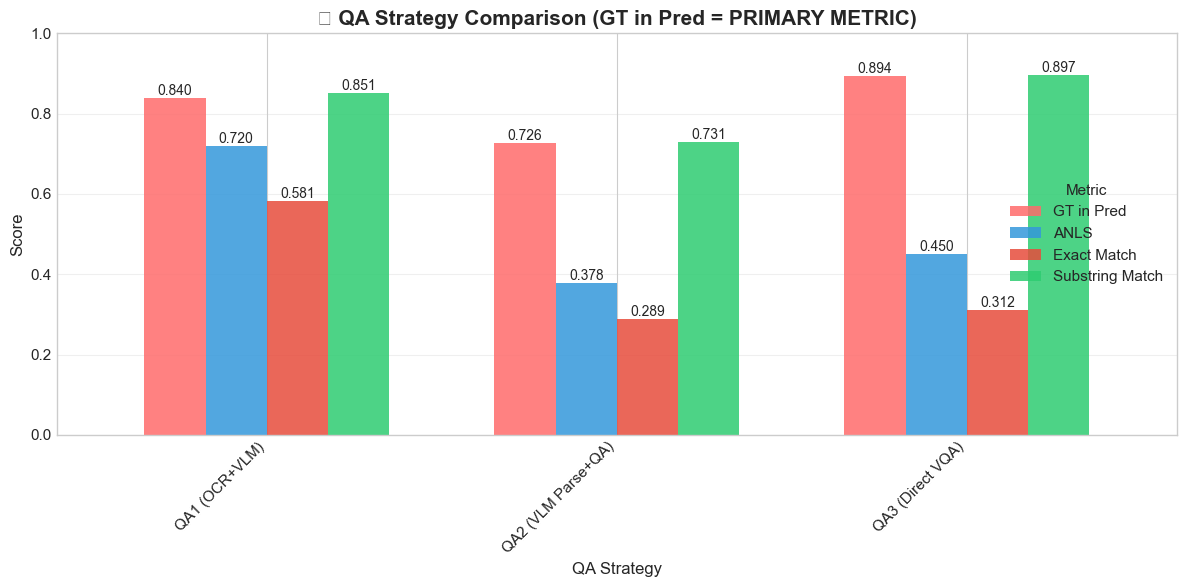

In [93]:
# Group phases by strategy
phase_groups = {
    'QA1 (OCR+VLM)': ['QA1a', 'QA1b', 'QA1c'],
    'QA2 (VLM Parse+QA)': ['QA2a', 'QA2b', 'QA2c'],
    'QA3 (Direct VQA)': ['QA3a', 'QA3b']
}

print("\nPhase Strategy Comparison:")
print("=" * 100)

strategy_results = []
for group_name, phases in phase_groups.items():
    group_data = summary_df[summary_df['Phase'].isin(phases)]
    if len(group_data) > 0:
        avg_gt_in_pred = group_data['GT in Pred'].mean()
        avg_anls = group_data['ANLS'].mean()
        avg_em = group_data['Exact Match'].mean()
        avg_substring = group_data['Substring Match'].mean()
        
        print(f"\n{group_name}:")
        print(f"  🎯 Mean GT in Pred: {avg_gt_in_pred:.4f} [PRIMARY]")
        print(f"     Mean ANLS: {avg_anls:.4f}")
        print(f"     Mean Exact Match: {avg_em:.4f}")
        print(f"     Mean Substring Match: {avg_substring:.4f}")
        print(f"  Phases included: {', '.join(phases)}")
        
        strategy_results.append({
            'Strategy': group_name,
            'GT in Pred': avg_gt_in_pred,  # PRIMARY FIRST
            'ANLS': avg_anls,
            'Exact Match': avg_em,
            'Substring Match': avg_substring
        })

# Visualize strategy comparison (PRIMARY METRIC FIRST)
if strategy_results:
    strategy_df = pd.DataFrame(strategy_results)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    strategy_df.set_index('Strategy')[['GT in Pred', 'ANLS', 'Exact Match', 'Substring Match']].plot(
        kind='bar', ax=ax, color=['#FF6B6B', '#3498db', '#e74c3c', '#2ecc71'], alpha=0.85, width=0.7
    )
    ax.set_title('🎯 QA Strategy Comparison (GT in Pred = PRIMARY METRIC)', fontsize=15, fontweight='bold')
    ax.set_xlabel('QA Strategy', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.legend(title='Metric', loc='best', fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_ylim(0, 1.0)
    
    # Add value labels
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=10)
    
    plt.tight_layout()
    plt.show()

## 13. Sample-Level Error Analysis

Identify easiest and hardest questions to understand error patterns.

In [94]:
# Analyze best and worst performing samples
if len(phase_dfs) > 0:
    analysis_phase = list(phase_dfs.keys())[0]
    df_error_analysis = phase_dfs[analysis_phase].copy()
    
    # Get first model for analysis
    pred_cols = [col for col in df_error_analysis.columns if col.startswith('prediction_')]
    first_model = pred_cols[0].replace('prediction_', '')
    
    # Calculate ANLS for each sample
    anls_scores = []
    for _, row in df_error_analysis.iterrows():
        ground_truths = parse_ground_truths(row['ground_truths'])
        anls = compute_anls(str(row[f'prediction_{first_model}']), ground_truths, threshold=0.5)
        anls_scores.append(anls)
    
    df_error_analysis['anls'] = anls_scores
    
    # Get best and worst samples
    best_samples = df_error_analysis.nlargest(10, 'anls')
    worst_samples = df_error_analysis.nsmallest(10, 'anls')
    
    print("\n" + "="*120)
    print(f"EASIEST QUESTIONS (Highest ANLS) - Model: {get_model_display_name(first_model)}")
    print("="*120)
    
    for _, row in best_samples.iterrows():
        print(f"\nSample: {row['sample_id']} | ANLS: {row['anls']:.4f}")
        print(f"Question: {str(row['question'])[:100]}..." if len(str(row['question'])) > 100 else f"Question: {row['question']}")
        
        ground_truths = parse_ground_truths(row['ground_truths'])
        gt_display = ', '.join([f'"{gt}"' for gt in ground_truths[:3]])
        if len(ground_truths) > 3:
            gt_display += f" ... (+{len(ground_truths)-3} more)"
        print(f"Ground Truths: {gt_display}")
        
        pred_text = str(row[f'prediction_{first_model}'])
        print(f"Prediction: {pred_text[:100]}..." if len(pred_text) > 100 else f"Prediction: {pred_text}")
    
    print("\n" + "="*120)
    print(f"HARDEST QUESTIONS (Lowest ANLS) - Model: {get_model_display_name(first_model)}")
    print("="*120)
    
    for _, row in worst_samples.iterrows():
        print(f"\nSample: {row['sample_id']} | ANLS: {row['anls']:.4f}")
        print(f"Question: {str(row['question'])[:100]}..." if len(str(row['question'])) > 100 else f"Question: {row['question']}")
        
        ground_truths = parse_ground_truths(row['ground_truths'])
        gt_display = ', '.join([f'"{gt}"' for gt in ground_truths[:3]])
        if len(ground_truths) > 3:
            gt_display += f" ... (+{len(ground_truths)-3} more)"
        print(f"Ground Truths: {gt_display}")
        
        pred_text = str(row[f'prediction_{first_model}'])
        print(f"Prediction: {pred_text[:100]}..." if len(pred_text) > 100 else f"Prediction: {pred_text}")


EASIEST QUESTIONS (Highest ANLS) - Model: Azure Intelligence → GPT-5 Mini

Sample: docvqa_mini_0003 | ANLS: 1.0000
Question: What is the word in double quote?
Ground Truths: "matching", "Matching"
Prediction: matching

Sample: docvqa_mini_0008 | ANLS: 1.0000
Question: What is Project Name ?
Ground Truths: "Seattle Region Name Generation Card"
Prediction: Seattle Region Name Generation Card

Sample: docvqa_mini_0009 | ANLS: 1.0000
Question: What is the Program # ?
Ground Truths: "701998"
Prediction: 701998

Sample: docvqa_mini_0010 | ANLS: 1.0000
Question: What is the page number?
Ground Truths: "- 5 -", "5"
Prediction: 5

Sample: docvqa_mini_0011 | ANLS: 1.0000
Question: Who is the Chief Executive Officer ( see the bottom part of the letter)?
Ground Truths: "Howard C. Harder"
Prediction: Howard C. Harder

Sample: docvqa_mini_0016 | ANLS: 1.0000
Question: How many ‘total implanted’?
Ground Truths: "1100"
Prediction: 1100

Sample: docvqa_mini_0018 | ANLS: 1.0000
Question: how much is th

## 14. Inference Time Analysis

Analyze speed vs accuracy trade-offs across strategies.


Inference Time Summary:


,Phase,Model,Mean Time (ms),Median Time (ms),Strategy
1,QA1a,mistral_document_ai__gpt-5-mini,5737.765616,5121.022582,QA1 (OCR+VLM)
0,QA1a,azure_intelligence__gpt-5-mini,6871.804197,5698.948145,QA1 (OCR+VLM)
3,QA1b,mistral_document_ai__gpt-5-mini,5608.246081,5091.107368,QA1 (OCR+VLM)
2,QA1b,azure_intelligence__gpt-5-mini,6485.472407,5464.203477,QA1 (OCR+VLM)
5,QA1c,mistral_document_ai__gpt-5-mini,7295.687834,6807.071447,QA1 (OCR+VLM)
4,QA1c,azure_intelligence__gpt-5-mini,7884.633410,6996.329904,QA1 (OCR+VLM)
7,QA2a,gpt-5-mini__gpt-5-mini,18140.170071,16755.878568,QA2 (VLM Parse+QA)
6,QA2a,claude_sonnet__claude_sonnet,19236.773110,17639.788628,QA2 (VLM Parse+QA)
8,QA2a,gpt-5-nano__gpt-5-nano,34474.366341,35085.165143,QA2 (VLM Parse+QA)
10,QA2b,gpt-5-mini__gpt-5-mini,17096.642528,15882.519364,QA2 (VLM Parse+QA)


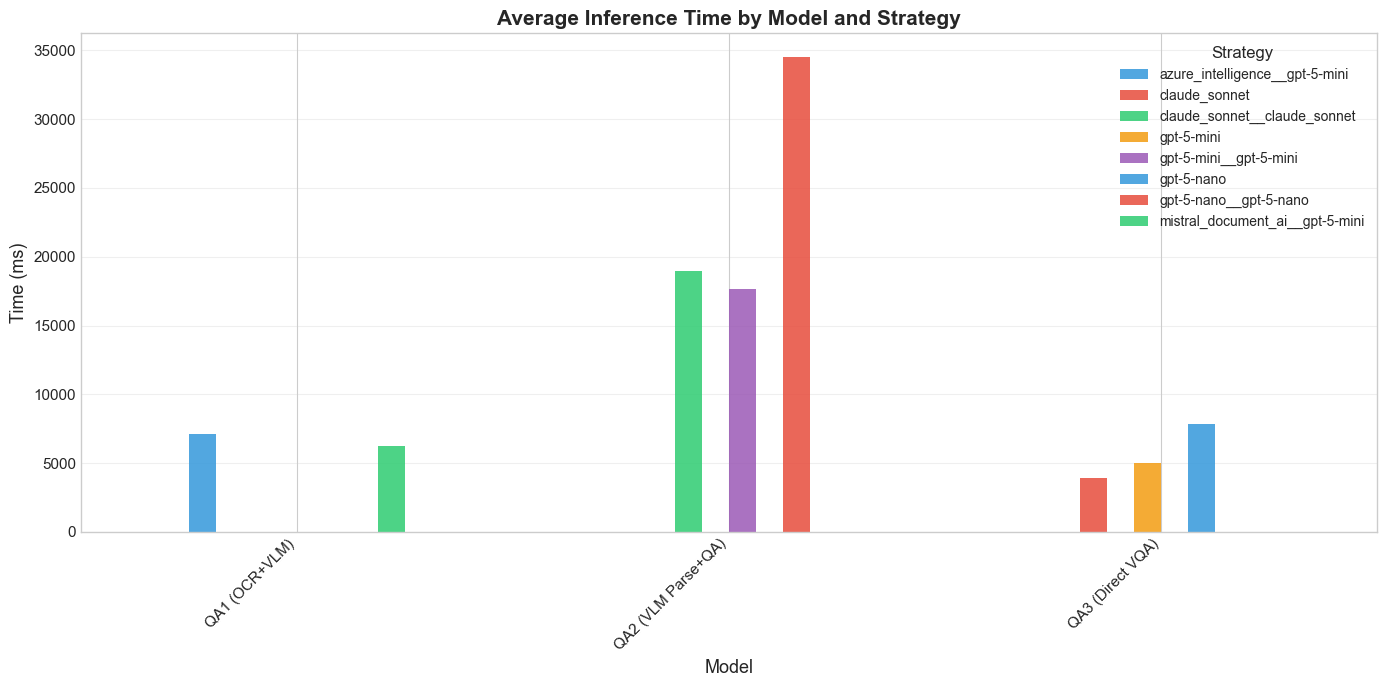

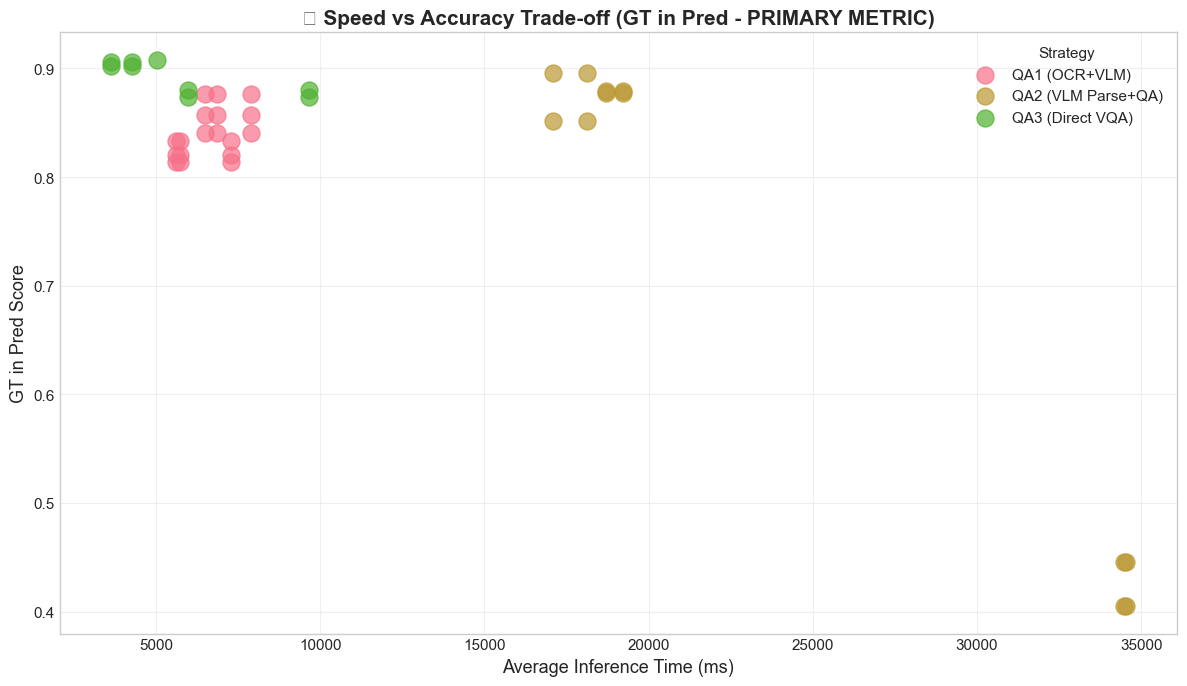

In [95]:
# Analyze inference times across models and phases
inference_data = []

for phase, df in phase_dfs.items():
    time_cols = [col for col in df.columns if col.startswith('inference_time_ms_')]
    
    for time_col in time_cols:
        model = time_col.replace('inference_time_ms_', '')
        
        mean_time = df[time_col].mean()
        median_time = df[time_col].median()
        
        inference_data.append({
            'Phase': phase,
            'Model': model,
            'Mean Time (ms)': mean_time,
            'Median Time (ms)': median_time
        })

if inference_data:
    inference_df = pd.DataFrame(inference_data)
    
    # Add strategy column
    inference_df['Strategy'] = inference_df['Phase'].apply(get_phase_strategy)
    
    print("\nInference Time Summary:")
    print("="*120)
    display(inference_df.sort_values(['Phase', 'Mean Time (ms)']))
    
    # Visualization - aggregate by strategy
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # Aggregate by strategy
    strategy_time = inference_df.groupby(['Strategy', 'Model'])['Mean Time (ms)'].mean().unstack()
    strategy_time = strategy_time.reindex(sort_models(strategy_time.index.tolist()))
    strategy_time.plot(kind='bar', ax=ax, color=colors_palette[:len(strategy_time.columns)], alpha=0.85)
    
    ax.set_title('Average Inference Time by Model and Strategy', fontsize=15, fontweight='bold')
    ax.set_xlabel('Model', fontsize=13)
    ax.set_ylabel('Time (ms)', fontsize=13)
    ax.legend(title='Strategy', title_fontsize=12, fontsize=10, loc='best')
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels([get_model_display_name(t.get_text()) for t in ax.get_xticklabels()], 
                       rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
    
    # Speed vs Accuracy scatter plot
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Merge inference time with GT in Pred scores (PRIMARY METRIC)
    speed_accuracy = pd.merge(
        inference_df[['Strategy', 'Model', 'Mean Time (ms)']],
        summary_df[['Strategy', 'Model', 'GT in Pred']],
        on=['Strategy', 'Model']
    )
    
    for strategy in speed_accuracy['Strategy'].unique():
        strategy_data = speed_accuracy[speed_accuracy['Strategy'] == strategy]
        ax.scatter(strategy_data['Mean Time (ms)'], strategy_data['GT in Pred'], 
                  s=150, alpha=0.7, label=strategy)
    
    ax.set_title('🎯 Speed vs Accuracy Trade-off (GT in Pred - PRIMARY METRIC)', fontsize=15, fontweight='bold')
    ax.set_xlabel('Average Inference Time (ms)', fontsize=13)
    ax.set_ylabel('GT in Pred Score', fontsize=13)
    ax.legend(title='Strategy', loc='best')
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No inference time data available")

## 15. DocVQA-Specific Analysis

Analyze document-specific patterns and field extraction accuracy.

In [96]:
# Analyze performance on different document types (if metadata available)
# This section can be customized based on available metadata

print("\nDocVQA-Specific Analysis:")
print("=" * 100)
print("\nKey Findings:")
print("- Document-centric questions often involve forms, reports, and scanned documents")
print("- Questions typically require extracting specific fields (dates, names, numbers)")
print("- OCR quality has significant impact on QA performance")
print("\nRecommendations for field extraction:")
print("- Use high-quality OCR (Azure Intelligence, Mistral Document AI) for structured documents")
print("- Direct VQA (QA3) may work better for visual reasoning questions")
print("- Consider hybrid approach: OCR for extraction + VLM for reasoning")


DocVQA-Specific Analysis:

Key Findings:
- Document-centric questions often involve forms, reports, and scanned documents
- Questions typically require extracting specific fields (dates, names, numbers)
- OCR quality has significant impact on QA performance

Recommendations for field extraction:
- Use high-quality OCR (Azure Intelligence, Mistral Document AI) for structured documents
- Direct VQA (QA3) may work better for visual reasoning questions
- Consider hybrid approach: OCR for extraction + VLM for reasoning


## 16. LLM Query Section

This section is a placeholder for analyzing the notebook outputs using an LLM.

### Key Questions to Investigate:

1. **Phase Strategy Performance:**
   - Which phase strategy works best? (QA1 vs QA2 vs QA3)
   - Does OCR quality matter for QA performance?
   - When should we use two-step pipeline vs direct VQA?

2. **Model Comparison:**
   - Which model performs best overall for document QA?
   - Are there trade-offs between different models (speed vs accuracy)?
   - Which model offers best balance for production use?

3. **Question Type Patterns:**
   - Which question types are easiest/hardest?
   - Do certain models excel at specific question types?
   - Are extractive vs reasoning questions handled differently?

4. **Error Analysis:**
   - What patterns exist in hardest questions?
   - Common failure modes (hallucination, incomplete answers, wrong field)?
   - How does ANLS correlate with semantic similarity?

5. **Production Recommendations:**
   - Best model/phase combination for document QA?
   - When to use OCR pipeline vs direct VQA?
   - Cost-effectiveness analysis (speed vs accuracy vs API cost)?

## 17. Save Embeddings Cache

Save any newly computed embeddings to disk for faster future runs.

In [97]:
# Save any remaining embeddings to disk for future use
print("\n📁 Finalizing embedding cache...")

if embedding_manager.modified_phases:
    print(f"Saving embeddings for modified phases: {embedding_manager.modified_phases}")
    
    for phase in embedding_manager.modified_phases:
        if phase in embedding_manager.cache:
            saved_file = save_embeddings_for_phase(
                dataset_name=DATASET_NAME,
                phase=phase,
                embeddings_dict=embedding_manager.cache[phase],
                embeddings_base_dir=EMBEDDINGS_DIR
            )
            print(f"✅ Saved: {saved_file.name}")
    
    print("\n✅ All embeddings have been persisted to disk!")
else:
    print("✅ No new embeddings to save (all from cache)")


📁 Finalizing embedding cache...
✅ No new embeddings to save (all from cache)


## 18. Conclusion

This notebook provides a comprehensive analysis of DocVQA document question answering performance across multiple models and QA strategies.

**Key Deliverables:**
- Quantitative QA metrics (ANLS, EM, Substring Match, Cosine Similarity) for all models
- Phase strategy comparison (OCR+VLM vs VLM Parse+QA vs Direct VQA)
- Visual comparisons across phases and models
- Question type and answer length analysis
- Sample-level error analysis identifying strengths and weaknesses
- Inference time benchmarks and speed vs accuracy trade-offs

**Next Steps:**
- Use LLM to generate natural language insights from results
- Identify specific question types or document layouts that cause issues
- Recommend optimal model selection strategy for document QA
- Investigate OCR quality impact on downstream QA performance
- Explore hybrid approaches combining OCR and direct VQA strengths

## 19. Best Model Comparison Across Strategies

Compare the best performing model from each QA strategy group.

🎯 BEST MODELS BY QA STRATEGY (GT in Pred - PRIMARY METRIC)
  QA1 (OCR+VLM): Azure Intelligence → GPT-5 Mini
    From QA1b: GT in Pred = 0.876268 [PRIMARY]
    ANLS: 0.8406, EM: 0.7444

  QA2 (VLM Parse+QA): GPT-5 Mini → GPT-5 Mini
    From QA2b: GT in Pred = 0.895582 [PRIMARY]
    ANLS: 0.8683, EM: 0.7791

  QA3 (Direct VQA): GPT-5 Mini
    From QA3b: GT in Pred = 0.908000 [PRIMARY]
    ANLS: 0.6322, EM: 0.4820



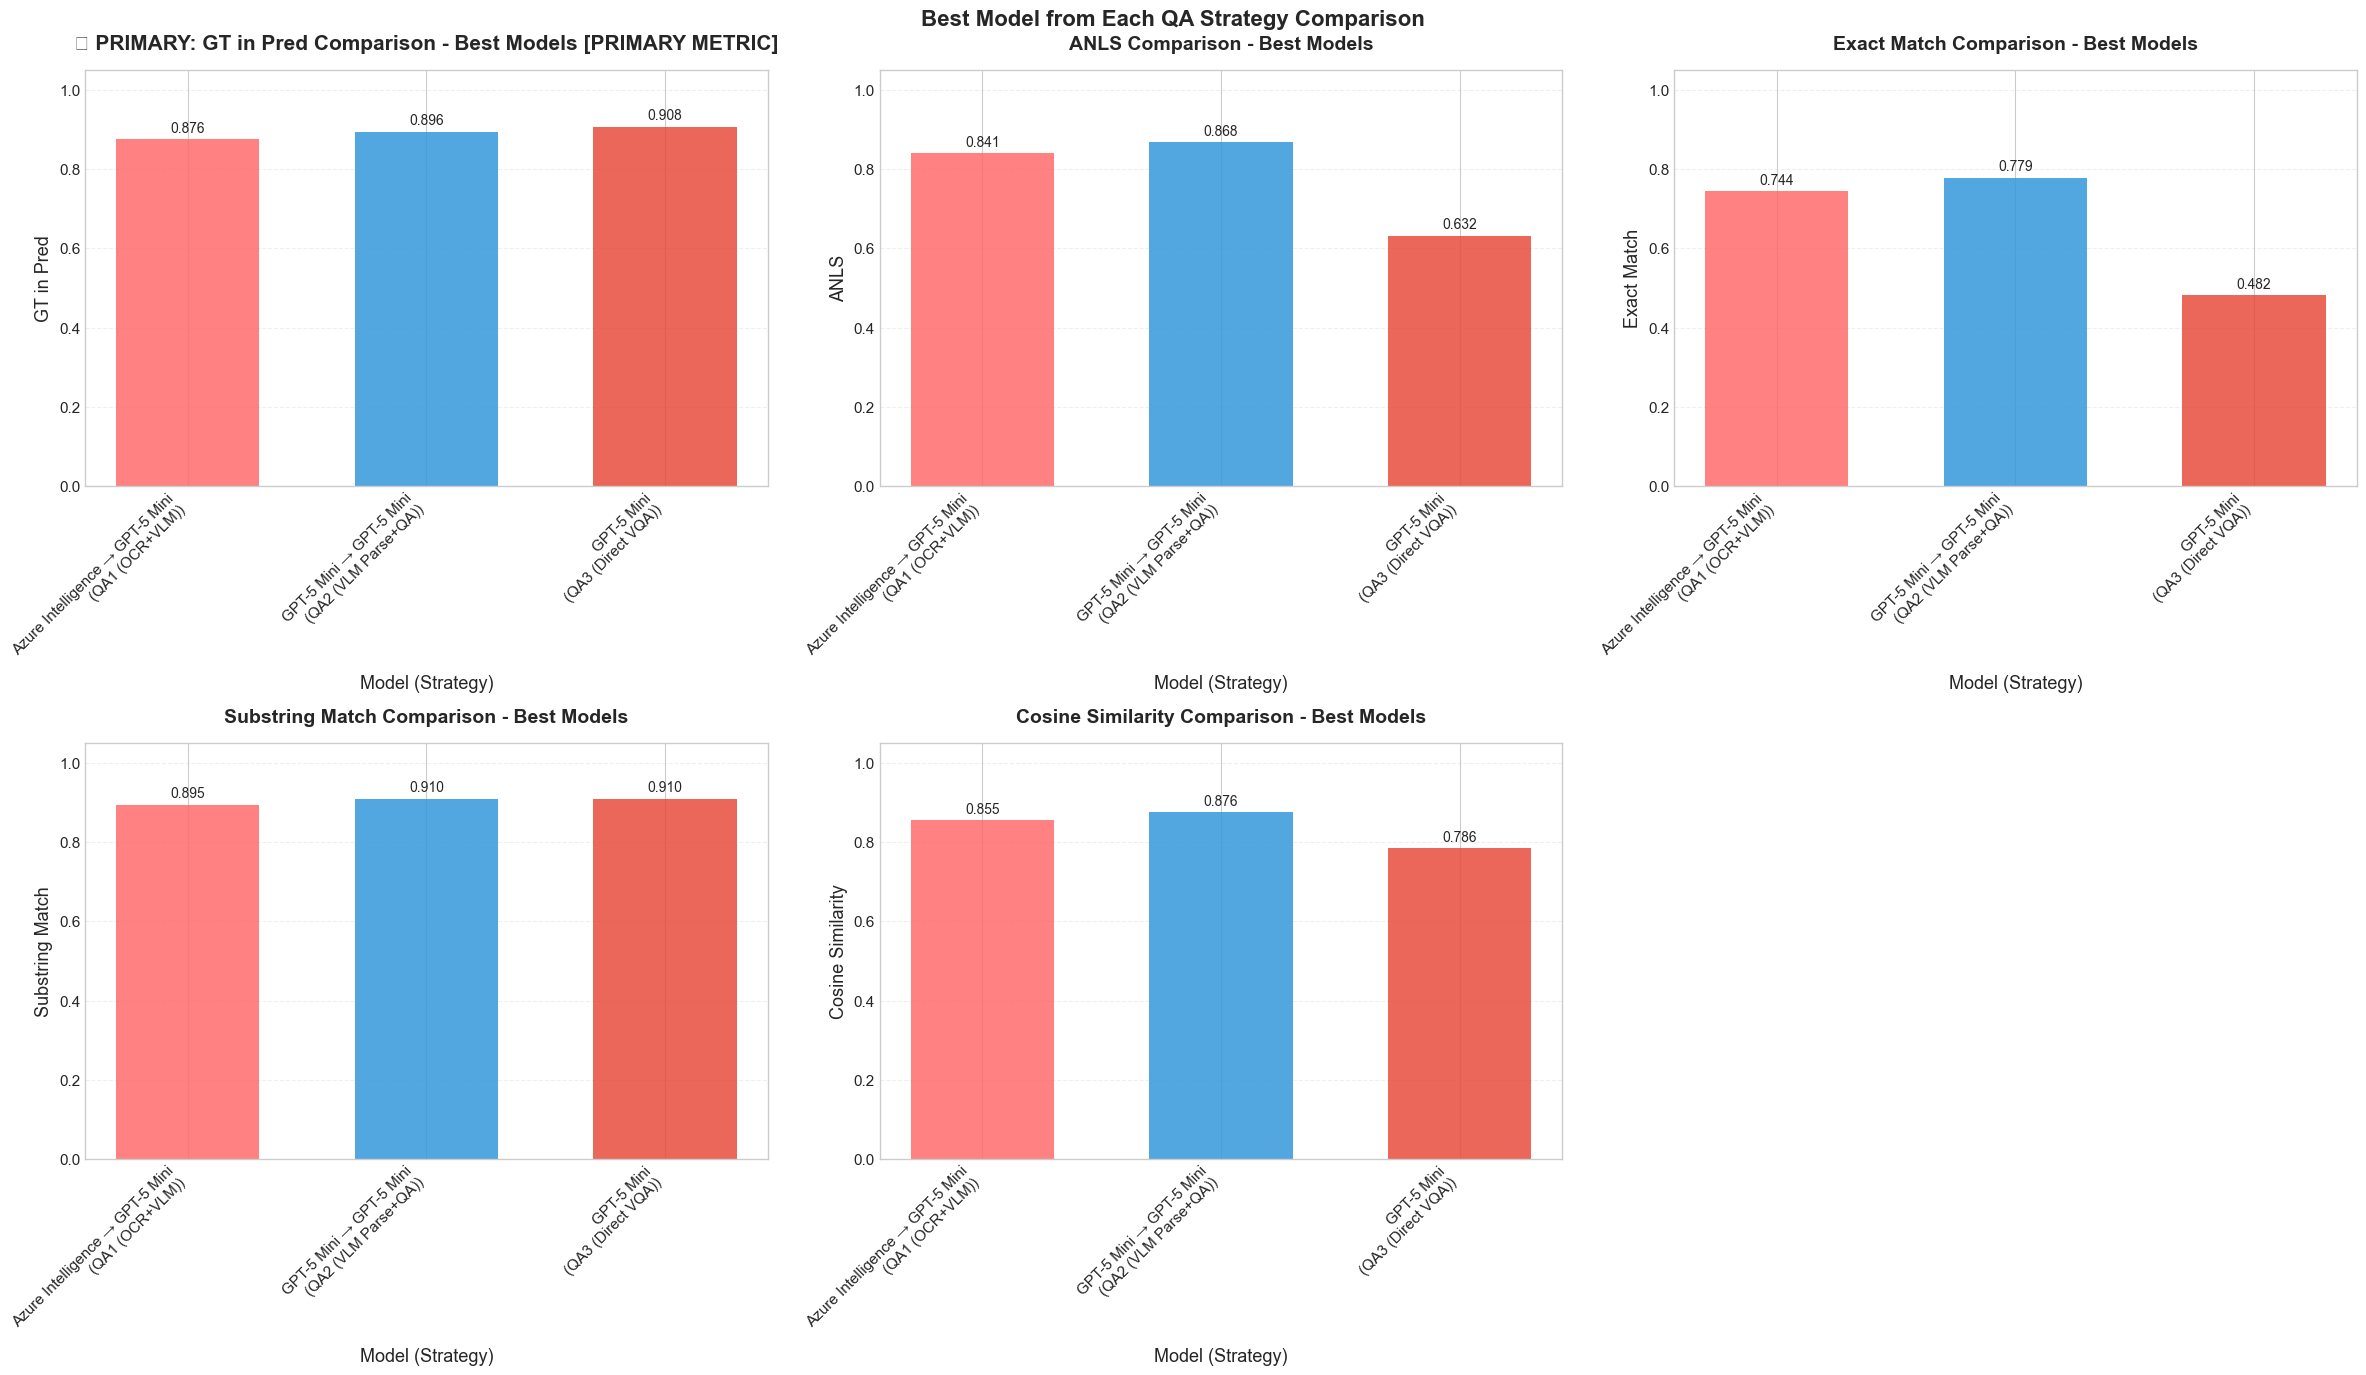


🎯 Note: "GT in Pred" (Ground Truth in Prediction) is the PRIMARY metric
Showing best model from each strategy: QA1 (OCR+VLM), QA2 (VLM Parse+QA), QA3 (Direct VQA)

🏆 OVERALL BEST MODEL:
  GPT-5 Mini (QA3 (Direct VQA))
  GT in Pred: 0.908000 [PRIMARY]


In [98]:
# Compare the best model from each QA strategy group
print("🎯 BEST MODELS BY QA STRATEGY (GT in Pred - PRIMARY METRIC)")
print("=" * 120)

# Find best model for each strategy
best_models = {}
for strategy in summary_df["Strategy"].unique():
    strategy_data = summary_df[summary_df["Strategy"] == strategy]
    best_idx = strategy_data["GT in Pred"].idxmax()
    best_model = strategy_data.loc[best_idx]
    best_models[strategy] = best_model

# Display best models
for strategy, model_data in best_models.items():
    print(f"  {strategy}: {get_model_display_name(model_data["Model"])}")
    print(f"    From {model_data["Phase"]}: GT in Pred = {model_data["GT in Pred"]:.6f} [PRIMARY]")
    print(f"    ANLS: {model_data["ANLS"]:.4f}, EM: {model_data["Exact Match"]:.4f}")
    print()

# Select the best model-phase combinations for visualization
best_models_data = pd.DataFrame(list(best_models.values()))

# Add a combined model-strategy label for display
best_models_data["Model-Strategy"] = best_models_data.apply(
    lambda row: f"{get_model_display_name(row["Model"])}\n({row["Strategy"]})", axis=1
)

# Create figure for best models comparison
fig, axes = plt.subplots(2, 3, figsize=(24, 14))
axes = axes.flatten()

# PRIMARY METRIC FIRST, then secondary metrics
metrics_to_plot = ["GT in Pred", "ANLS", "Exact Match", "Substring Match", "Cosine Similarity"]
colors_palette = ["#FF6B6B", "#3498db", "#e74c3c", "#2ecc71", "#9b59b6"]

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    
    # Plot data for each best model
    bars = ax.bar(range(len(best_models_data)), best_models_data[metric], 
                  color=colors_palette[:len(best_models_data)], alpha=0.85, width=0.6)
    
    # Emphasize primary metric
    title_prefix = "🎯 PRIMARY: " if metric == "GT in Pred" else ""
    title_suffix = " [PRIMARY METRIC]" if metric == "GT in Pred" else ""
    
    ax.set_title(f"{title_prefix}{metric} Comparison - Best Models{title_suffix}", 
                fontsize=15 if metric == "GT in Pred" else 14, 
                fontweight="bold", pad=15)
    ax.set_xlabel("Model (Strategy)", fontsize=13)
    ax.set_ylabel(metric, fontsize=13)
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.set_xticks(range(len(best_models_data)))
    ax.set_xticklabels(best_models_data["Model-Strategy"], rotation=45, ha="right")
    ax.set_ylim(0, 1.05)
    
    # Add value labels on bars
    for bar, value in zip(bars, best_models_data[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f"{value:.3f}", ha="center", va="bottom", fontsize=10)

# Hide last subplot if not needed
if len(metrics_to_plot) < 6:
    axes[-1].set_visible(False)

plt.suptitle("Best Model from Each QA Strategy Comparison", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n🎯 Note: \"GT in Pred\" (Ground Truth in Prediction) is the PRIMARY metric")
print("Showing best model from each strategy: QA1 (OCR+VLM), QA2 (VLM Parse+QA), QA3 (Direct VQA)")
print("\n🏆 OVERALL BEST MODEL:")
overall_best = best_models_data.loc[best_models_data["GT in Pred"].idxmax()]
print(f"  {get_model_display_name(overall_best["Model"])} ({overall_best["Strategy"]})" )
print(f"  GT in Pred: {overall_best["GT in Pred"]:.6f} [PRIMARY]")

## 20. LLM Query Section

This section is a placeholder for analyzing the notebook outputs using an LLM.

### Key Questions to Investigate:

1. **Phase Strategy Performance:**
   - Which phase strategy works best? (QA1 vs QA2 vs QA3)
   - Does OCR quality matter for QA performance?
   - When should we use two-step pipeline vs direct VQA?

2. **Model Comparison:**
   - Which model performs best overall for document QA?
   - Are there trade-offs between different models (speed vs accuracy)?
   - Which model offers best balance for production use?

3. **Question Type Patterns:**
   - Which question types are easiest/hardest?
   - Do certain models excel at specific question types?
   - Are extractive vs reasoning questions handled differently?

4. **Error Analysis:**
   - What patterns exist in hardest questions?
   - Common failure modes (hallucination, incomplete answers, wrong field)?
   - How does ANLS correlate with semantic similarity?

5. **Production Recommendations:**
   - Best model/phase combination for document QA?
   - When to use OCR pipeline vs direct VQA?
   - Cost-effectiveness analysis (speed vs accuracy vs API cost)?